## 1. Introduction

**BQT-MDQW** is a small research prototype that stitches three ideas together:

1. `[ESTABLISHED]` **Quantum teleportation** — the Bennett *et al.* (1993) protocol, built as a Qiskit
   circuit and executed on the Qiskit Aer classical simulator.
2. `[SIMULATED]` **A discrete-time coined quantum walk** — standard quantum-walk formalism
   (shunt decomposition, coin and shift operators) propagated with dense NumPy matrix-vector
   products and, for cross-validation, as a Qiskit circuit on Aer.
3. `[PROPOSED]` **An MDQW-inspired routing layer** — a multi-metric link cost, a per-relay hop
   penalty, and an *optional* node-salience prior derived from the walk. This is a **classical**
   graph search (A* / uniform-cost) over a synthetic network graph.

The name expands to *Bidirectional Quantum Teleportation with a Multi-dimensional Quantum Walk*
heuristic — but the "MDQW" in the routing function is a **design label, not a quantum algorithm**.

### What this prototype is *not*

> **This is a research prototype. Every single result in this notebook is a classical simulation.**
>
> * `[SIMULATED]` No quantum hardware, optical link or network device was involved. Every quantum
>   operation is executed by **Qiskit Aer's classical simulator** or by dense NumPy
>   matrix-vector products.
> * `[PROPOSED]` The routing layer is a **classical graph algorithm** inspired by quantum-walk
>   concepts. It is **not** a quantum algorithm, it is not run on a quantum computer, and **no
>   quantum advantage, speed-up or scaling property is claimed or implied anywhere**.
> * `[PROPOSED]` Nothing here demonstrates **physical quantum communication**. The network
>   topology and every one of its five link metrics is synthetic.
> * `[PROPOSED]` Nothing here demonstrates **simultaneous bidirectional teleportation**. The
>   six-qubit "bidirectional" circuit is a composite *model* — see section 4 for exactly what it
>   does and does not show.
> * `[SIMULATED]` **MDQW is not claimed to beat Dijkstra.** On the instances in this notebook they
>   tie, because with no node terms they minimise the *same* objective. Section 8 reports the
>   verdict that was actually observed.

### Provenance tags used throughout

| Tag | Meaning |
| --- | --- |
| `[ESTABLISHED]` | Published, textbook results: the teleportation protocol, Dijkstra's algorithm, the coined-walk formalism (Kendon) and the shunt decomposition (Wong). |
| `[PROPOSED]` | Design choices made in *this* repository. No external citation, no hardware validation. |
| `[SIMULATED]` | Every number. Produced by Aer or by NumPy on synthetic data. |

### What you will actually see

* A three-qubit teleportation circuit drawn, run, marginalised and scored — including a noisy
  control run.
* A six-qubit two-channel "bidirectional" model with its assumptions stated up front.
* A coined quantum walk on a 4-cycle, with the shunt decomposition verified numerically and the
  Aer distribution cross-checked against the exact NumPy reference (**the real validation number**).
* A six-node network, a multi-metric router, a Dijkstra baseline, and an honest comparison.
* A hop-by-hop multi-hop simulation with the "this is not a repeater network" warning attached.

## 2. Environment setup

`[SIMULATED]` This section makes `import src...` work, prints the software stack the rest of the
notebook runs on, and prints the simulation disclaimer that the project itself emits.

Two things are done here:

1. **Path setup.** The notebook lives in `simulations/`, so `src/` is one directory up. Both a
   `cwd`-relative and a `.resolve()`-based insert are used so the import works whether nbconvert is
   launched from the repo root or from `simulations/`.
2. **Matplotlib.** `%matplotlib inline` is applied so figures land in the notebook. It is invoked
   programmatically (`get_ipython().run_line_magic("matplotlib", "inline")`) and guarded, so the
   cell still runs on a kernel where the magic is unavailable; in that case the non-interactive
   `Agg` backend is selected instead.

Note also that `stdout` is reconfigured to UTF-8 where the kernel supports it. Qiskit's text
circuit drawer emits box-drawing characters, and a `cp1252` console would raise
`UnicodeEncodeError` on them.

In [1]:
# --- %matplotlib inline, applied programmatically and guarded -----------------
_inline_applied = False
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # == `%matplotlib inline`
    _inline_applied = True
except Exception as exc:                                    # pragma: no cover
    print("inline magic unavailable ({}); falling back to Agg".format(exc))

import matplotlib
if not _inline_applied:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

# --- make `import src...` work from the simulations/ directory ---------------
import sys
import pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
sys.path.insert(0, str(pathlib.Path('..').resolve()))

# --- UTF-8 stdout, so qiskit's box-drawing text drawing can be printed --------
try:
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
    print("stdout reconfigured to utf-8")
except Exception as exc:
    print("stdout reconfigure unavailable ({}); ASCII-only output from here".format(exc))

print()
print("cwd                :", pathlib.Path.cwd())
print("repo root on path  :", str(pathlib.Path('..').resolve()))
print("matplotlib backend :", matplotlib.get_backend())
print("inline applied     :", _inline_applied)

stdout reconfigure unavailable ('OutStream' object has no attribute 'reconfigure'); ASCII-only output from here

cwd                : C:\Users\Sanju\Projects\BQT-MDQW\simulations
repo root on path  : C:\Users\Sanju\Projects\BQT-MDQW
matplotlib backend : inline
inline applied     : True


In [2]:
# --- verify qiskit is importable, then print the project's own env reports ----
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

from src.quantum_teleportation import environment_report as teleportation_environment_report
from src.quantum_walk import environment_report as walk_environment_report
from src.simulation import environment_block

_probe = QuantumCircuit(1, 1, name="import-probe")
_probe.h(0)
_probe.measure(0, 0)
print("qiskit importable  :", qiskit.__version__)
print("AerSimulator       :", type(AerSimulator()).__name__)
print("qiskit builds a circuit and transpiles:", end=" ")
from qiskit import transpile
_t = transpile(_probe, AerSimulator(), optimization_level=0, seed_transpiler=1)
print(_t.count_ops())
print()

print("=" * 78)
print(teleportation_environment_report())
print()
print("=" * 78)
print(walk_environment_report())
print()
print("=" * 78)
print(environment_block())
print("=" * 78)

qiskit importable  : 2.5.2
AerSimulator       : AerSimulator
qiskit builds a circuit and transpiles: OrderedDict({'h': 1, 'measure': 1})

BQT-MDQW quantum teleportation environment
python              : 3.12.10
qiskit              : 2.5.2
qiskit-aer          : 0.17.2
numpy               : 2.5.3
platform            : Windows-11-10.0.26300-SP0
machine             : AMD64
results             : SIMULATED -- every quantum result produced by this
                      project comes from Qiskit Aer's classical simulator.
                      No result was measured on quantum hardware, and no
                      link metric in this project is calibrated against a
                      physical device.

BQT-MDQW quantum walk environment
python                : 3.12.10 (win32)
numpy                 : 2.5.3
networkx              : 3.7
matplotlib            : 3.11.2 (backend inline)
qiskit                : 2.5.2
qiskit-aer            : 0.17.2

SIMULATED: the discrete-time coined quantum walk in

In [3]:
# Every public name this notebook uses, imported once, in one place.
import math
import os
import tempfile

import networkx as nx
import numpy as np
import pandas as pd

from IPython.display import Image, display

from src.network import (
    EdgeMetrics,
    QuantumNetwork,
    build_example_network,
    minmax_normalize,
    random_network,
)
from src.mdqw_routing import (
    DEFAULT_WEIGHTS,
    DijkstraBaseline,
    MDQWConfig,
    MDQWRouter,
    RouteResult,
    RoutingError,
    RoutingWeights,
    compare_routes,
    enumerate_routes,
    summarise_comparison,
    walkable_proxy,
)
from src.quantum_teleportation import (
    ArbitraryState,
    bell_pair_entanglement_demo,
    bidirectional_marginals,
    bidirectional_teleportation_circuit,
    build_branch_circuits,
    build_noise_model,
    build_teleportation_circuit,
    branch_marginal,
    environment_report,
    fidelity_metrics,
    marginal_counts,
    run_on_aer,
    teleport_link_with_noise,
)
from src.quantum_walk import (
    build_walk_circuit,
    coin_operator,
    example_walk_graph,
    initial_state,
    max_distribution_error,
    node_probability_distribution,
    plot_walk_evolution,
    plot_walk_heatmap,
    quantum_walk_prior,
    shift_operator,
    shunt_decomposition,
    stationary_node_distribution,
    walk_on_aer,
    walk_reference_numpy,
)
from src.simulation import (
    HopResult,
    MultiHopResult,
    environment_block as _environment_block,
    fidelity_vs_hop_count,
    plot_network_topology,
    render_architecture_diagram,
    run_all,
    simulate_route,
)

# --- a scratch directory for every figure and every generated report ---------
FIGDIR = pathlib.Path(tempfile.gettempdir()) / "bqt_mdqw_demo_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)
print("scratch figure directory:", FIGDIR)

# One master seed for the whole notebook.
SEED = 20260930
np.random.seed(SEED)   # only for the cosmetic random_network demo below
print("cells assembled:", len(cells) if 'cells' in dir() else "n/a")

scratch figure directory: C:\Users\Sanju\AppData\Local\Temp\bqt_mdqw_demo_figures
cells assembled: n/a


## 3. Quantum teleportation

`[ESTABLISHED]` The protocol is the one of Bennett *et al.*, PRL **70**, 1895 (1993).
`[SIMULATED]` Everything printed below is produced by Qiskit Aer, a classical simulator.

### The state

`[ESTABLISHED]` A generic single-qubit pure state in Bloch-sphere polar/azimuthal form is

$$|\psi\rangle = \cos\theta\,|0\rangle + e^{i\phi}\sin\theta\,|1\rangle,$$

so $\theta \in [0, \pi/2]$ is the polar angle off $+z$ and $\phi$ is the equatorial phase. This is
exactly the right parameterisation for teleportation, because the protocol *destroys* Alice's
copy: $\theta$ and $\phi$ are all that is known a priori, and they fix the distribution Bob has to
reproduce without ever learning the amplitudes.

We use a non-trivial, non-equatorial, non-eigenstate:

$$\theta = 52^\circ \approx 0.9076\ \text{rad},\qquad \phi = 37^\circ \approx 0.6458\ \text{rad},$$

whose ideal computational-basis distribution is $\{0: 0.379039,\; 1: 0.620961\}$.

### Qubit / classical-bit layout

```
q0 = Alice's payload qubit      c0 = outcome of Alice's measurement of q0
q1 = Alice's half of the Bell pair   c1 = outcome of Alice's measurement of q1
q2 = Bob's qubit (reconstruction)    c2 = Bob's readout of q2
```

### Correction convention

`[ESTABLISHED]` After Alice's Bell-basis measurement Bob holds $X^{c_1}Z^{c_0}|\psi\rangle$, so the
recovery is **X driven by `c1`** (Alice's *Bell-pair* qubit) and **Z driven by `c0`** (Alice's
*payload* qubit). Getting that pairing backwards still produces a perfectly running circuit that
is silently wrong, which is why the notebook prints the circuit rather than trusting it.

In [4]:
STATE = ArbitraryState(theta=math.radians(52.0), phi=math.radians(37.0))
IDEAL = STATE.ideal_probabilities()

print("state   :", STATE.as_label())
print("theta   : {:.6f} rad = {:.1f} deg".format(STATE.theta, math.degrees(STATE.theta)))
print("phi     : {:.6f} rad = {:.1f} deg".format(STATE.phi, math.degrees(STATE.phi)))
print("statevector     :", np.round(STATE.as_statevector(), 6))
print("ideal probs     :", {k: round(v, 6) for k, v in IDEAL.items()},
      " (sums to {:.12f})".format(sum(IDEAL.values())))
print()
print("Only theta matters for a computational-basis measurement -- phi never appears in IDEAL.")

CIRCUIT = build_teleportation_circuit(STATE, dynamic=True)
print()
print("circuit name     :", CIRCUIT.name)
print("qubits / clbits  :", CIRCUIT.num_qubits, "/", CIRCUIT.num_clbits)
print("depth            :", CIRCUIT.depth())
print("operations       :", dict(CIRCUIT.count_ops()))

state   : cos(0.9075712110370514)|0> + exp(i*0.6457718232379019)*sin(0.9075712110370514)|1>
theta   : 0.907571 rad = 52.0 deg
phi     : 0.645772 rad = 37.0 deg
statevector     : [0.615661+0.j       0.629333+0.474237j]
ideal probs     : {'0': 0.379039, '1': 0.620961}  (sums to 1.000000000000)

Only theta matters for a computational-basis measurement -- phi never appears in IDEAL.

circuit name     : teleport
qubits / clbits  : 3 / 3
depth            : 7
operations       : {'measure': 3, 'h': 2, 'cx': 2, 'if_else': 2, 'ry': 1, 'rz': 1}


mpl drawing produced: True

circuit.draw('text')
     ┌────────────┐┌─────────────┐     ┌───┐┌─┐                          »
q_0: ┤ Ry(1.8151) ├┤ Rz(0.64577) ├──■──┤ H ├┤M├──────────────────────────»
     └───┬───┬────┘└─────────────┘┌─┴─┐└┬─┬┘└╥┘                          »
q_1: ────┤ H ├────────────■───────┤ X ├─┤M├──╫───────────────────────────»
         └───┘          ┌─┴─┐     └───┘ └╥┘  ║   ┌──────  ┌───┐ ───────┐ »
q_2: ───────────────────┤ X ├────────────╫───╫───┤ If-0  ─┤ X ├  End-0 ├─»
                        └───┘            ║   ║   └──╥───  └───┘ ───────┘ »
                                         ║   ║ ┌────╨────┐               »
c: 3/════════════════════════════════════╩═══╩═╡ c_1=0x1 ╞═══════════════»
                                         1   0 └─────────┘               »
«                                  
«q_0: ─────────────────────────────
«                                  
«q_1: ─────────────────────────────
«       ┌──────  ┌───┐ ───────┐ ┌─┐
«q_2: ──┤ If-0  ─┤ Z 

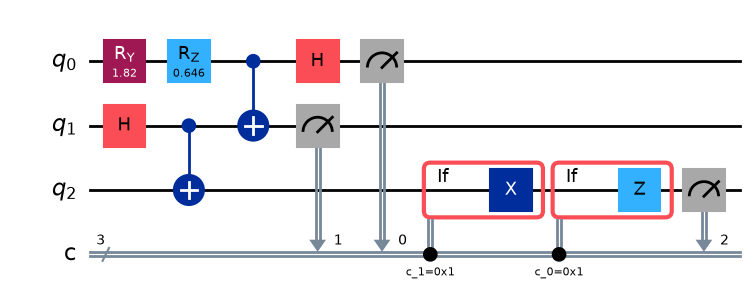

In [5]:
# --- draw the circuit ---------------------------------------------------------
# Qiskit's Matplotlib drawer needs `pylatexenc` for gate labels; it is pinned in
# requirements.txt, so a normal install draws this with no extra step. The call is
# still guarded, so a stripped-down environment degrades to the text drawing
# rather than failing the notebook.
_mpl_drawn = False
try:
    _fig = CIRCUIT.draw("mpl")
    _mpl_drawn = True
except Exception as exc:
    print("circuit.draw('mpl') unavailable ->", type(exc).__name__, str(exc).split(".")[0])
print("mpl drawing produced:", _mpl_drawn)
print()
print("=" * 78)
print("circuit.draw('text')")
print("=" * 78)
print(CIRCUIT.draw("text"))

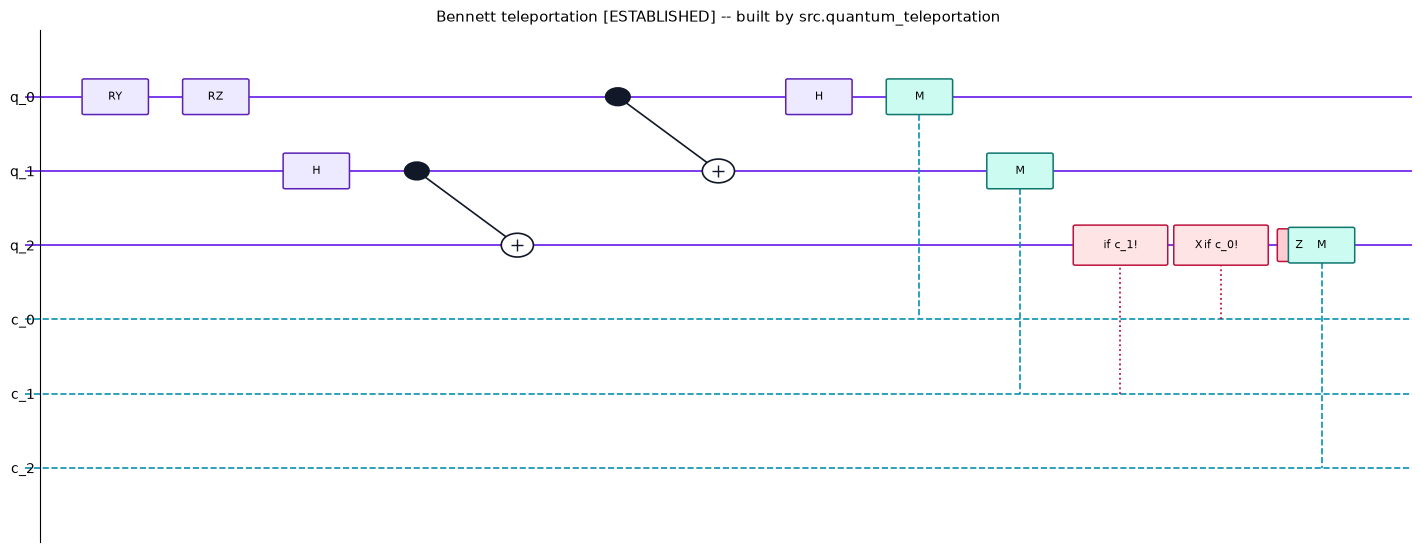

In [6]:
# --- schematic drawn here, with plain matplotlib -------------------------------
# Gate positions are read out of the real circuit, so this cannot silently drift
# from the circuit that is actually executed. conditional gate labels come from
# the IfElseOp bodies themselves.
import matplotlib.pyplot as plt

def draw_schematic(circuit, title):
    # Draw a minimal gate-position schematic of `circuit` with plain matplotlib.
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle, FancyBboxPatch

    nq, nc = circuit.num_qubits, circuit.num_clbits
    rows = [("q", i) for i in range(nq)] + [("c", i) for i in range(nc)]
    ypos = {key: float(len(rows) - 1 - index) for index, key in enumerate(rows)}
    ticklabels = {key: "{}_{}".format(key[0], key[1]) for key in rows}

    def gate_label(operation):
        # The conditional gate label is read out of the IfElseOp block itself, so
        # the picture can never disagree with the circuit that gets executed.
        if operation.name == "if_else" and operation.blocks:
            counts = operation.blocks[0].count_ops()
            for candidate in ("x", "z", "h", "s", "y"):
                if counts.get(candidate):
                    return candidate.upper()
            return "IF"
        return operation.name.upper()

    layout = []
    column = 0
    for instruction in circuit.data:
        operation = instruction.operation
        name = operation.name
        qubits = [circuit.find_bit(q).index for q in instruction.qubits]
        clbits = [circuit.find_bit(c).index for c in instruction.clbits]
        span = 2 if name == "cx" else 1
        layout.append((column, span, name, gate_label(operation), qubits, clbits))
        column += span
    total = max(1, column)

    fig, ax = plt.subplots(figsize=(max(7.0, 0.95 * total + 2.0), 0.62 * len(rows) + 1.9))
    for key, y in ypos.items():
        style = dict(color="#7c3aed", linewidth=1.4) if key[0] == "q" \
            else dict(color="#0891b2", linewidth=1.2, linestyle="--")
        ax.axhline(y, **style, zorder=0)

    def box(x, y, w, h, label, face, edge, fontsize=8):
        ax.add_patch(FancyBboxPatch(
            (x - w / 2.0, y - h / 2.0), w, h,
            boxstyle="round,pad=0.02", facecolor=face, edgecolor=edge,
            linewidth=1.1, zorder=3))
        ax.text(x, y, label, ha="center", va="center", fontsize=fontsize, zorder=4)

    for x, span, name, label, qubits, clbits in layout:
        if name == "cx":
            control, target = qubits
            ax.plot([x, x + span - 1], [ypos[("q", control)], ypos[("q", target)]],
                    color="#111827", linewidth=1.2, zorder=2)
            ax.add_patch(Circle((x, ypos[("q", control)]), 0.13,
                                facecolor="#111827", zorder=4))
            ax.add_patch(Circle((x + span - 1, ypos[("q", target)]), 0.16,
                                facecolor="white", edgecolor="#111827",
                                linewidth=1.2, zorder=4))
            ax.plot([x + span - 1], [ypos[("q", target)]], marker="+", markersize=9,
                    color="#111827", zorder=5)
        elif name == "measure":
            q, c = qubits[0], clbits[0]
            ax.plot([x, x], [ypos[("q", q)], ypos[("c", c)]],
                    color="#0891b2", linestyle="--", linewidth=1.2, zorder=2)
            box(x, ypos[("q", q)], 0.62, 0.44, "M", "#ccfbf1", "#0f766e")
        elif name == "if_else":
            q = qubits[0]
            cond = clbits[0]
            ax.plot([x, x], [ypos[("c", cond)], ypos[("q", q)]],
                    color="#be123c", linestyle=":", linewidth=1.3, zorder=2)
            box(x, ypos[("q", q)], 0.9, 0.5, "if c_{}!".format(cond), "#ffe4e6", "#be123c")
            box(x + 0.78, ypos[("q", q)], 0.4, 0.4, label, "#fecdd3", "#be123c")
        elif name == "barrier":
            ax.plot([x, x], [ypos[rows[0]], ypos[rows[-1]]],
                    color="#9ca3af", linestyle="-.", linewidth=0.9, zorder=1)
        else:
            for q in qubits:
                box(x, ypos[("q", q)], 0.62, 0.44, label, "#ede9fe", "#5b21b6")

    ax.set_xlim(-0.9, total - 0.1)
    ax.set_ylim(-1.0, len(rows) - 0.1)
    ax.set_yticks([ypos[key] for key in rows])
    ax.set_yticklabels([ticklabels[key] for key in rows], fontsize=9)
    ax.set_xticks([])
    ax.set_title(title, fontsize=11)
    ax.spines["left"].set_position(("data", -0.75))
    ax.spines["left"].set_visible(True)
    for side in ("right", "top", "bottom"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="y", length=0)
    fig.tight_layout()
    return fig


draw_schematic(CIRCUIT, "Bennett teleportation [ESTABLISHED] -- built by src.quantum_teleportation")
plt.show()

### Running it on Aer

`[SIMULATED]` `run_on_aer` transpiles with `optimization_level=0` (which keeps the gate names intact
so the noise model still decorates the intended instructions, and makes the mapping deterministic
for a fixed seed) and runs `AerSimulator`. Aer's counts keys are bitstrings in which the **leftmost
character is the most significant classical bit**, so a key reads `c2 c1 c0`.

`marginal_counts(counts, bit_index=2)` sums over the other bits to extract **Bob's** readout. The
counts will be close to uniform over the eight `c1c0` outcomes — that is expected and correct,
because Alice's outcome is uniformly distributed over the four Bell states *for every* `|psi⟩` and
carries no information about the state at all. What must be reproduced is Bob's marginal.

In [7]:
COUNTS = run_on_aer(CIRCUIT, shots=4096, seed=SEED)

print("Aer counts (key = c2 c1 c0), {} shots:".format(sum(COUNTS.values())))
for key in sorted(COUNTS):
    print("  {}  {:>5}   ({:.4f})".format(key, COUNTS[key], COUNTS[key] / sum(COUNTS.values())))
print()
print("Alice's c1c0 marginal (expected ~uniform, carries no info about |psi>):")
alice = marginal_counts(COUNTS, bit_index=0, num_bits=3)   # c0
bell = marginal_counts(COUNTS, bit_index=1, num_bits=3)    # c1
tot = sum(COUNTS.values())
print("  c0:", {k: round(v / tot, 4) for k, v in alice.items()})
print("  c1:", {k: round(v / tot, 4) for k, v in bell.items()})

Aer counts (key = c2 c1 c0), 4096 shots:
  000    417   (0.1018)
  001    351   (0.0857)
  010    381   (0.0930)
  011    395   (0.0964)
  100    629   (0.1536)
  101    649   (0.1584)
  110    631   (0.1541)
  111    643   (0.1570)

Alice's c1c0 marginal (expected ~uniform, carries no info about |psi>):
  c0: {'0': 0.5024, '1': 0.4976}
  c1: {'1': 0.5005, '0': 0.4995}


In [8]:
BOB = marginal_counts(COUNTS, bit_index=2, num_bits=3)
bob_total = sum(BOB.values())
OBSERVED = {key: value / bob_total for key, value in BOB.items()}
METRICS = fidelity_metrics(OBSERVED, IDEAL)

print("Bob's marginal (bit_index=2)      :", BOB)
print("Bob's normalised distribution    :", {k: round(v, 6) for k, v in OBSERVED.items()})
print("ideal distribution               :", {k: round(v, 6) for k, v in IDEAL.items()})
print()
print("fidelity vs the ideal distribution:")
for name, value in METRICS.items():
    print("  {:<16s} {:.8f}".format(name, value))
print()
print("The Bhattacharyya coefficient is 1 only when the two distributions coincide, so the close")
print("to 1 value above is the statement that teleportation worked on this run.")

Bob's marginal (bit_index=2)      : {'0': 1544, '1': 2552}
Bob's normalised distribution    : {'0': 0.376953, '1': 0.623047}
ideal distribution               : {'0': 0.379039, '1': 0.620961}

fidelity vs the ideal distribution:
  bhattacharyya    0.99999537
  total_variation  0.00208593
  hellinger        0.00152095

The Bhattacharyya coefficient is 1 only when the two distributions coincide, so the close
to 1 value above is the statement that teleportation worked on this run.


### The four deterministic branch circuits

`[PROPOSED]` `build_branch_circuits` returns one circuit per Alice outcome, `"00"`, `"01"`, `"10"`
and `"11"`, with the label in `c1c0` order. The *protocol* is established; forcing a single
branch is a modelling choice, and the reason it is unavoidable is structural rather than clerical.

Right after Alice's measurement the joint state is

$$\tfrac12\big(|00\rangle X^0Z^0|\psi\rangle + |01\rangle X^1Z^0|\psi\rangle
+ |10\rangle X^0Z^1|\psi\rangle + |11\rangle X^1Z^1|\psi\rangle\big).$$

The four states $|\psi\rangle,\ X|\psi\rangle,\ Z|\psi\rangle,\ XZ|\psi\rangle$ are mutually
orthogonal for any $|\psi\rangle$, so the **reduced** state of Bob's qubit — Alice's qubits traced
out rather than measured — is proportional to $I + X^2 + Z^2 + (XZ)^2 = 4I$, i.e. exactly the
maximally mixed state, and no unitary can change that. Isolating one branch therefore *requires*
classical post-selection: run the full circuit, apply the branch's correction blindly, and keep
only the shots whose Alice bits match. That is also how deterministic-branch teleportation is
handled in linear optics.

In [9]:
BRANCHES = build_branch_circuits(STATE)
rows = []
for label in ("00", "01", "10", "11"):
    branch_counts = run_on_aer(BRANCHES[label], shots=4096, seed=SEED)
    marginal = branch_marginal(branch_counts, label, bit_index=2, num_bits=3)
    retained = sum(marginal.values())
    observed = {k: v / retained for k, v in marginal.items()}
    rows.append({
        "branch c1c0": label,
        "correction": ("I" if label == "00" else "X" if label == "01"
                       else "Z" if label == "10" else "X then Z"),
        "shots kept": retained,
        "shots discarded": sum(branch_counts.values()) - retained,
        "Bob P(0)": observed.get("0", 0.0),
        "Bob P(1)": observed.get("1", 0.0),
        "Bhattacharyya": fidelity_metrics(observed, IDEAL)["bhattacharyya"],
    })
branches_frame = pd.DataFrame(rows)
print(branches_frame.to_string(index=False))
print()
print("ideal Bob P(0) = {:.6f}".format(IDEAL["0"]))
print("Every branch reproduces the same distribution, so the correction algebra is consistent")
print("across all four Pauli outcomes. Roughly three quarters of the shots are thrown away,")
print("which is the price of forcing a deterministic branch.")

branch c1c0 correction  shots kept  shots discarded  Bob P(0)  Bob P(1)  Bhattacharyya
         00          I        1053             3043  0.366572  0.633428       0.999834
         01          X         998             3098  0.387776  0.612224       0.999919
         10          Z        1004             3092  0.369522  0.630478       0.999903
         11   X then Z        1014             3082  0.374753  0.625247       0.999980

ideal Bob P(0) = 0.379039
Every branch reproduces the same distribution, so the correction algebra is consistent
across all four Pauli outcomes. Roughly three quarters of the shots are thrown away,
which is the price of forcing a deterministic branch.


### A noisy control run

`[PROPOSED]` `build_noise_model(strength, readout_error=...)` decorates the one- and two-qubit gate
sets with depolarising channels and adds a symmetric readout confusion matrix. **The mapping from
this project's abstract `noise` / `fidelity` link attributes onto concrete Aer channels is a choice
made in this repository.** It is not a calibrated device characterisation, and a real apparatus
would need gate-specific infidelities and a measured confusion matrix.

Here we ask for a modest depolarising strength of `0.02` and a `0.01` readout error, and compare
against the ideal run.

In [10]:
NOISE_STRENGTH, READOUT_ERROR = 0.02, 0.01
NOISE_MODEL = build_noise_model(NOISE_STRENGTH, readout_error=READOUT_ERROR)
noisy_counts = run_on_aer(CIRCUIT, shots=4096, seed=SEED, noise_model=NOISE_MODEL)
noisy_bob = marginal_counts(noisy_counts, bit_index=2, num_bits=3)
noisy_total = sum(noisy_bob.values())
noisy_observed = {k: v / noisy_total for k, v in noisy_bob.items()}
noisy_metrics = fidelity_metrics(noisy_observed, IDEAL)

print("noise model: depolarising strength = {:.3f}, readout error = {:.3f}".format(
    NOISE_STRENGTH, READOUT_ERROR))
print("noisy Bob marginal :", noisy_bob)
print("noisy distribution :", {k: round(v, 6) for k, v in noisy_observed.items()})
print()
comparison = pd.DataFrame([
    {"run": "ideal Aer", **{k: round(v, 8) for k, v in METRICS.items()}},
    {"run": "noisy Aer", **{k: round(v, 8) for k, v in noisy_metrics.items()}},
])
print(comparison.to_string(index=False))
print()
print("Both scores moved the wrong way: the Bhattacharyya coefficient fell from {:.6f} to {:.6f}".format(
    METRICS["bhattacharyya"], noisy_metrics["bhattacharyya"]))
print("and the total variation distance to the ideal distribution rose from {:.6f} to {:.6f}.".format(
    METRICS["total_variation"], noisy_metrics["total_variation"]))
print("That is the degradation we expected, and it is the only quantitative claim made here.")

noise model: depolarising strength = 0.020, readout error = 0.010
noisy Bob marginal : {'0': 1588, '1': 2508}
noisy distribution : {'0': 0.387695, '1': 0.612305}

      run  bhattacharyya  total_variation  hellinger
ideal Aer       0.999995         0.002086   0.001521
noisy Aer       0.999921         0.008656   0.006295

Both scores moved the wrong way: the Bhattacharyya coefficient fell from 0.999995 to 0.999921
and the total variation distance to the ideal distribution rose from 0.002086 to 0.008656.
That is the degradation we expected, and it is the only quantitative claim made here.


## 4. Bidirectional teleportation — a *concept model*, not a demonstration

> ### ⚠️ Read this before quoting anything from this section
>
> * `[PROPOSED]` **A Bell pair is unidirectional.** Two nodes cannot send quantum states to each
>   other through a *single* entangled pair, because teleportation **consumes** the entanglement
>   and leaves Alice with nothing to teleport from.
> * `[PROPOSED]` Genuine simultaneous bidirectional teleportation therefore requires **two
>   independent entangled pairs and two independent classical channels**. The circuit below builds
>   exactly that — and nothing more.
> * `[SIMULATED]` Aer runs it as **one composite six-qubit state**. That is a convenient way to
>   exercise the routing layer; it is **not** a demonstration of physical simultaneous bidirectional
>   teleportation. Running both channels in a single circuit **hides the resource accounting** that
>   a real two-way link must pay for (two pair-establishment protocols, two classical channels, two
>   feed-forward round trips), and it contains **no decoherence, no repeater buffering and no
>   finite propagation delay**.
> * `[SIMULATED]` The two channels share no qubits and no classical bits, so they are independent
>   *by construction*. Their marginals are statistically independent by construction too, and their
>   joint correlation therefore carries no extra structure.

### Layout

```
q0 = A's payload             q3 = B's payload
q1 = A's half of pair AB     q4 = B's half of pair BA
q2 = B's receiver            q5 = A's receiver

creg "a2b" (c0,c1,c2) : the A -> B classical channel
creg "b2a" (c3,c4,c5) : the B -> A classical channel
```

A counts key therefore reads `c5c4c3c2c1c0`; Bob's readout of Alice's payload is `c2`, and Alice's
readout of Bob's payload is `c5`.

In [11]:
STATE_AB = ArbitraryState(theta=math.radians(52.0), phi=math.radians(37.0))    # Alice -> Bob
STATE_BA = ArbitraryState(theta=math.radians(28.0), phi=math.radians(115.0))   # Bob -> Alice

BIDI = bidirectional_teleportation_circuit(STATE_AB, STATE_BA, dynamic=True)

print("circuit name    :", BIDI.name)
print("qubits / clbits :", BIDI.num_qubits, "/", BIDI.num_clbits)
print("registers       :", [r.name for r in BIDI.cregs])
print("operation count :", sum(BIDI.count_ops().values()), dict(BIDI.count_ops()))
print()
print("NOTE: this circuit is rendered by qiskit's own matplotlib drawer, not a")
print("hand-rolled schematic. That works because every if_test condition refers to a")
print("clbit owned by this outer circuit. An earlier build instead composed two")
print("sub-circuits, which left the feed-forward conditions pointing at a detached")
print("'c' register; both qiskit drawers then failed on the resulting IfElseOp. The")
print("instruction list is printed below so the gate order stays legible without")
print("rendering, and the next cell draws the decomposed circuit so the conditional")
print("blocks expand into explicit gates.")
for index, instruction in enumerate(BIDI.data):
    qubits = [BIDI.find_bit(q).index for q in instruction.qubits]
    clbits = [BIDI.find_bit(c).index for c in instruction.clbits]
    print("  {:2d}  {:<9s} q={} c={}".format(index, instruction.operation.name, qubits, clbits))

circuit name    : teleport-bidirectional
qubits / clbits : 6 / 6
registers       : ['a2b', 'b2a']
operation count : 22 {'measure': 6, 'h': 4, 'cx': 4, 'if_else': 4, 'ry': 2, 'rz': 2}

NOTE: this circuit is rendered by qiskit's own matplotlib drawer, not a
hand-rolled schematic. That works because every if_test condition refers to a
clbit owned by this outer circuit. An earlier build instead composed two
sub-circuits, which left the feed-forward conditions pointing at a detached
'c' register; both qiskit drawers then failed on the resulting IfElseOp. The
instruction list is printed below so the gate order stays legible without
rendering, and the next cell draws the decomposed circuit so the conditional
blocks expand into explicit gates.
   0  ry        q=[0] c=[]
   1  rz        q=[0] c=[]
   2  h         q=[1] c=[]
   3  cx        q=[1, 2] c=[]
   4  cx        q=[0, 1] c=[]
   5  h         q=[0] c=[]
   6  measure   q=[0] c=[0]
   7  measure   q=[1] c=[1]
   8  if_else   q=[2] c=[1]
  

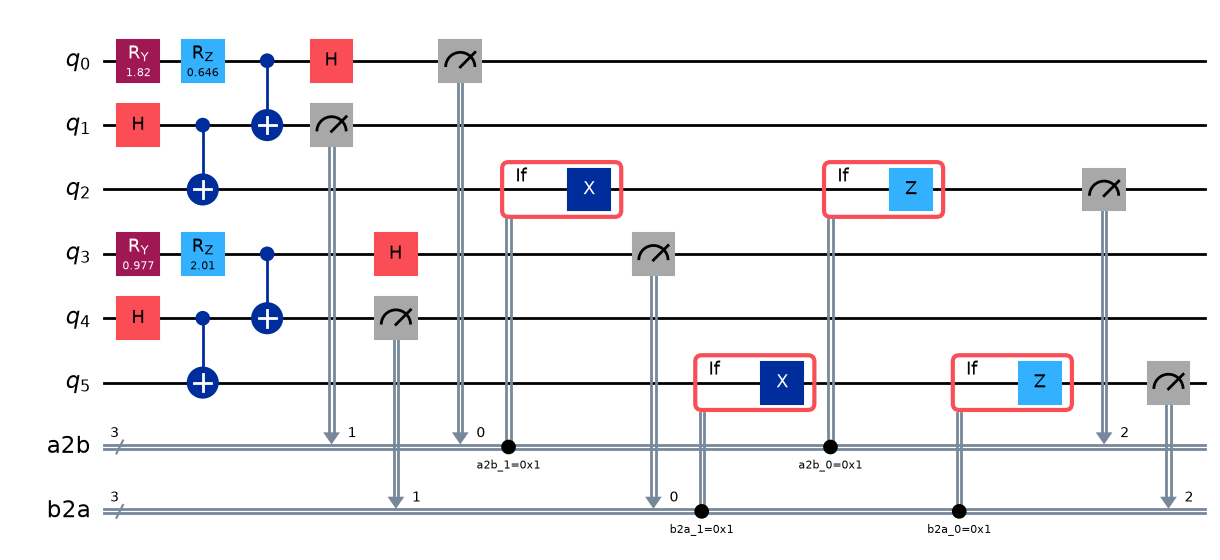

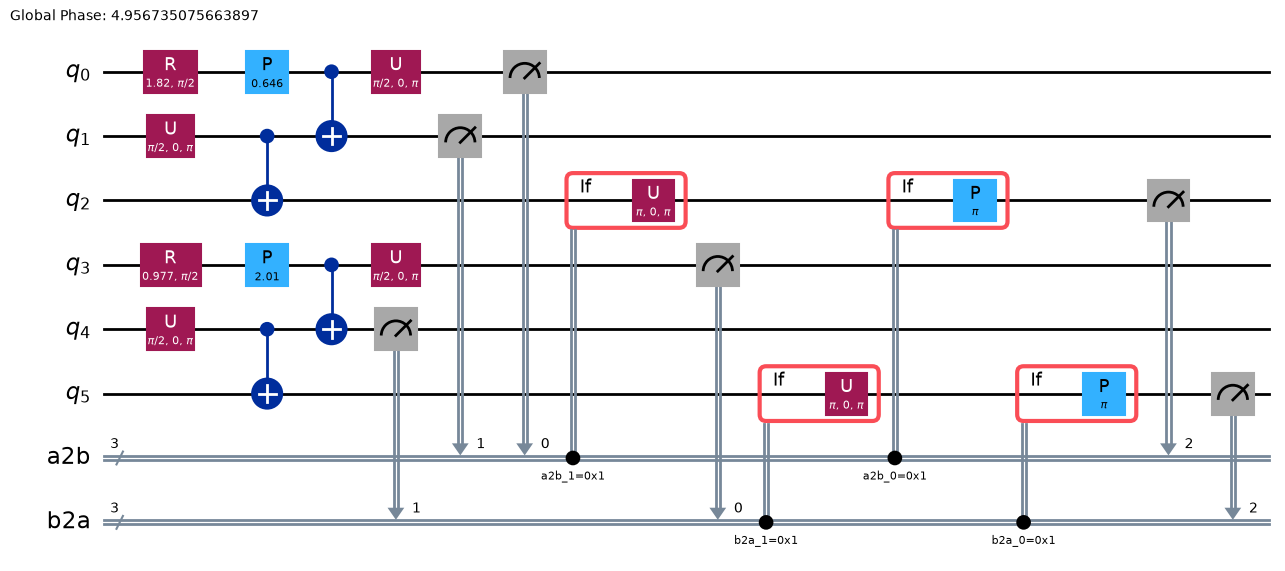

In [12]:
# Both renderings below come straight from the circuit that was executed above.
# The decomposed form expands each if_test block into explicit conditional gates,
# which is the clearest way to see the feed-forward corrections on the receiver.
BIDI.draw("mpl")
BIDI.decompose().draw("mpl")
plt.show()

In [13]:
BIDI_COUNTS = run_on_aer(BIDI, shots=4096, seed=SEED)
a_recovered, b_recovered = bidirectional_marginals(BIDI_COUNTS)

a_total, b_total = sum(a_recovered.values()), sum(b_recovered.values())
a_observed = {k: v / a_total for k, v in a_recovered.items()}   # Alice's readout of Bob's state
b_observed = {k: v / b_total for k, v in b_recovered.items()}   # Bob's readout of Alice's state

a_metrics = fidelity_metrics(a_observed, STATE_BA.ideal_probabilities())   # B -> A channel
b_metrics = fidelity_metrics(b_observed, STATE_AB.ideal_probabilities())   # A -> B channel

print("distinct 6-bit outcome keys :", len(BIDI_COUNTS), "(4 Alice outcomes x 4 Bob outcomes per direction)")
print()
print("A -> B channel   (Bob's readout of Alice's payload, bit c2)")
print("   ideal        :", {k: round(v, 6) for k, v in STATE_AB.ideal_probabilities().items()})
print("   recovered    :", {k: round(v, 6) for k, v in b_observed.items()})
print("   Bhattacharyya: {:.8f}".format(b_metrics["bhattacharyya"]))
print("   total var.   : {:.8f}".format(b_metrics["total_variation"]))
print()
print("B -> A channel   (Alice's readout of Bob's payload, bit c5)")
print("   ideal        :", {k: round(v, 6) for k, v in STATE_BA.ideal_probabilities().items()})
print("   recovered    :", {k: round(v, 6) for k, v in a_observed.items()})
print("   Bhattacharyya: {:.8f}".format(a_metrics["bhattacharyya"]))
print("   total var.   : {:.8f}".format(a_metrics["total_variation"]))
print()
print("Both directions transfer independently and at high fidelity, and both channels were")
print("teleporting *different* states -- which is precisely the point of the model, and also")
print("precisely the reason it does not demonstrate simultaneous bidirectional teleportation.")

distinct 6-bit outcome keys : 64 (4 Alice outcomes x 4 Bob outcomes per direction)

A -> B channel   (Bob's readout of Alice's payload, bit c2)
   ideal        : {'0': 0.379039, '1': 0.620961}
   recovered    : {'0': 0.376953, '1': 0.623047}
   Bhattacharyya: 0.99999537
   total var.   : 0.00208593

B -> A channel   (Alice's readout of Bob's payload, bit c5)
   ideal        : {'0': 0.779596, '1': 0.220404}
   recovered    : {'1': 0.217041, '0': 0.782959}
   Bhattacharyya: 0.99998346
   total var.   : 0.00336253

Both directions transfer independently and at high fidelity, and both channels were
teleporting *different* states -- which is precisely the point of the model, and also
precisely the reason it does not demonstrate simultaneous bidirectional teleportation.


`[SIMULATED]` `bell_pair_entanglement_demo` prepares two *independent* Bell pairs on four qubits
and returns the exact 16-amplitude statevector. No mid-circuit measurement is used, so the
statevector is exact rather than a statistical estimate — but it is still a classical simulation.

In [14]:
bell_circuit, bell_state = bell_pair_entanglement_demo()
nonzero = np.nonzero(np.abs(bell_state) > 1e-9)[0]
print("qubits / state length :", bell_circuit.num_qubits, "/", bell_state.shape)
print("norm                  : {:.12f}".format(float(np.linalg.norm(bell_state))))
print("non-zero basis indices:", nonzero.tolist())
print("amplitudes at those   :", np.round(np.abs(bell_state[nonzero]), 6).tolist())
print()
print("Qiskit's little-endian ordering means index i is the basis state whose bitstring is")
print("format(i, '04b'). The four non-zero entries are the two Bell products:")
for i in nonzero:
    print("   index {:2d}  =  |{}>".format(i, format(int(i), "04b")))
print()
print("('0011' and '1100') is the visible evidence of the SECOND pair's correlation, and the")
print("fact that all four outcomes agree qubit-by-qubit is the evidence of the FIRST pair's.")
print()
print("measurement distribution:", {format(int(i), "04b"): round(float(abs(bell_state[i]) ** 2), 4)
                                    for i in nonzero})

qubits / state length : 4 / (16,)
norm                  : 1.000000000000
non-zero basis indices: [0, 3, 12, 15]
amplitudes at those   : [0.5, 0.5, 0.5, 0.5]

Qiskit's little-endian ordering means index i is the basis state whose bitstring is
format(i, '04b'). The four non-zero entries are the two Bell products:
   index  0  =  |0000>
   index  3  =  |0011>
   index 12  =  |1100>
   index 15  =  |1111>

('0011' and '1100') is the visible evidence of the SECOND pair's correlation, and the
fact that all four outcomes agree qubit-by-qubit is the evidence of the FIRST pair's.

measurement distribution: {'0000': 0.25, '0011': 0.25, '1100': 0.25, '1111': 0.25}


## 5. Quantum walk demonstration

`[ESTABLISHED]` A **discrete-time coined quantum walk** (DTQW) on a graph. The formalism is Kendon's
coined walk; the adjacency split used here is Wong's **shunt decomposition**.
`[SIMULATED]` All numbers are classical: dense NumPy matrix-vector products, plus a Qiskit circuit on
Aer used purely as a cross-check.

### The mathematics

**The Hilbert space.** The walk lives in $\mathcal{H} = \mathcal{H}_{\text{coin}} \otimes
\mathcal{H}_{\text{position}}$. For an $m$-regular graph on $n$ nodes, $\dim\mathcal{H} = m n$, and
the flat basis index of a state is

$$ \lvert c\rangle_{\text{coin}} \otimes \lvert v\rangle_{\text{position}}
\;\longleftrightarrow\; c\,n + v, $$

with $c \in \{0,\dots,m-1\}$ the *coin* (which incident directed edge) and $v \in \{0,\dots,n-1\}$
the *node*. A node probability is obtained by marginalising over the coin,
$P(v) = \sum_c |\psi[c\,n+v]|^2$.

**The shunt decomposition.** On an $m$-regular graph the adjacency matrix $A$ can always be split

$$ A = P_0 + P_1 + \dots + P_{m-1}, $$

with every $P_i$ a **permutation matrix**: a disjoint union of directed cycles that follow graph
edges (a 2-cycle $u \to v \to u$ is the single edge $\{u,v\}$; a longer cycle is a cycle of $G$
traversed in one direction). This is the structural reason the walk needs a **regular** graph: only
then is there a fixed coin dimension $m$ for every node. The implementation extracts one *cycle
cover* of the residual digraph per round via a Hopcroft–Karp matching on the bipartite double
cover, which is why every shunt is a derangement and `sum(P_i) == A` holds *exactly*.

**The shift is a permutation.** The shunt shift is

$$ S = \sum_{i=0}^{m-1} \bigl(\lvert i\rangle\langle i\rvert_{\text{coin}} \otimes P_i\bigr), $$

a block-diagonal matrix with permutation blocks. Permutation matrices are unitary, so $S$ is
unitary — the walk is deterministic, exactly like a classical walk, and never destroys probability.
We verify both facts numerically below.

**One step.** The step operator is $U = S\,\bigl(C \otimes I_n\bigr)$: the coin acts first, mixing
the $m$ incident edges at the current node, then the shift moves the walker. After $t$ steps,
$\psi_t = U^t \psi_0$.

**What this is for.** The walk's *only* role in this project is to produce a node-salience prior
(section 7). It is **not** an algorithm for anything, its unitary is applied as a single dense
$(mn) \times (mn)$ matrix, and no quantum advantage is claimed.

graph            : 
nodes            : [0, 1, 2, 3]
edges            : [(0, 1), (0, 3), (1, 2), (2, 3)]
degrees          : {0: 2, 1: 2, 2: 2, 3: 2}
walk dimension m*n = 2 x 4 = 8



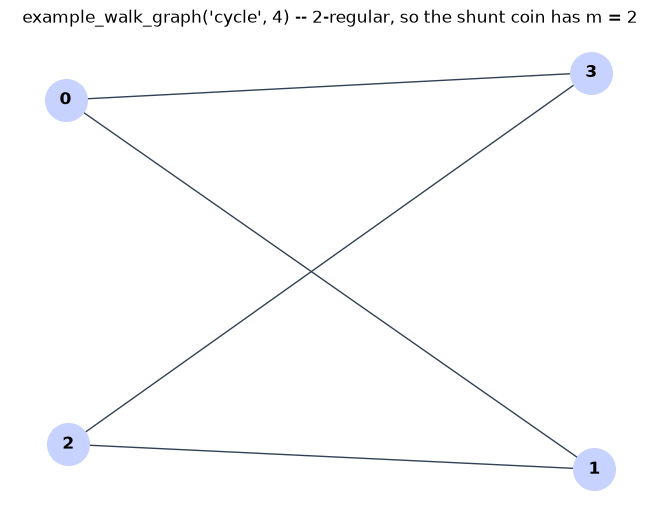

In [15]:
# --- a small regular graph: the 4-cycle.  m = 2, n = 4  =>  m*n = 8 amplitudes.
G = example_walk_graph("cycle", 4)
ORDER = list(G.nodes)
print("graph            :", G.name if hasattr(G, 'name') else "cycle_graph(4)")
print("nodes            :", ORDER)
print("edges            :", sorted(G.edges))
print("degrees          :", dict(G.degree()))
print("walk dimension m*n = {} x {} = {}".format(
    G.degree(ORDER[0]), G.number_of_nodes(),
    G.degree(ORDER[0]) * G.number_of_nodes()))
print()
G_DRAW = nx.draw(G, with_labels=True, node_color="#c7d2fe", node_size=900,
                 edge_color="#334155", font_weight="bold")
plt.axis("off")
plt.title("example_walk_graph('cycle', 4) -- 2-regular, so the shunt coin has m = 2")
plt.show()

In [16]:
# --- shunt decomposition: A = P_0 + P_1, each P_i a permutation matrix ---------
SHUNTS = shunt_decomposition(G)
ADJACENCY = nx.to_numpy_array(G, nodelist=ORDER, dtype=int)

print("m = {} shunts, each a {}x{} permutation matrix".format(
    len(SHUNTS), G.number_of_nodes(), G.number_of_nodes()))
print()
for index, shunt in enumerate(SHUNTS):
    one_per_row = bool((shunt.sum(axis=1) == 1).all())
    one_per_col = bool((shunt.sum(axis=0) == 1).all())
    binary = bool(np.isin(shunt, (0, 1)).all())
    is_permutation = one_per_row and one_per_col and binary
    print("P_{} =".format(index))
    print(shunt)
    print("  one 1 per row: {}   one 1 per column: {}   entries in {{0,1}}: {}   "
          "is a permutation matrix: {}".format(one_per_row, one_per_col, binary, is_permutation))
    print("  cycles: ", end="")
    # decode the shunt as directed arcs and report its cycle structure
    arcs = {(i, j) for i in range(G.number_of_nodes()) for j in range(G.number_of_nodes())
            if shunt[i, j]}
    seen, cycles = set(), []
    for start in range(G.number_of_nodes()):
        if start in seen:
            continue
        walk_cycle, node = [start], start
        seen.add(start)
        while True:
            nxt = next(j for i, j in arcs if i == node)
            if nxt == start:
                break
            walk_cycle.append(nxt)
            seen.add(nxt)
            node = nxt
        cycles.append(" -> ".join(map(str, walk_cycle)) + " -> " + str(start))
    print("; ".join(cycles))
    print()

print("adjacency A (node order {}):".format(ORDER))
print(ADJACENCY)
TOTAL = sum(SHUNTS)
print("P_0 + P_1 =")
print(TOTAL)
print()
print("sum(P_i) == A exactly :", np.array_equal(TOTAL, ADJACENCY))
print("every shunt is a derangement (no fixed points, so the sum has a zero diagonal):",
      all(int(np.trace(P)) == 0 for P in SHUNTS))

m = 2 shunts, each a 4x4 permutation matrix

P_0 =
[[0 1 0 0]
 [1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]]
  one 1 per row: True   one 1 per column: True   entries in {0,1}: True   is a permutation matrix: True
  cycles: 0 -> 1 -> 0; 2 -> 3 -> 2

P_1 =
[[0 0 0 1]
 [0 0 1 0]
 [0 1 0 0]
 [1 0 0 0]]
  one 1 per row: True   one 1 per column: True   entries in {0,1}: True   is a permutation matrix: True
  cycles: 0 -> 3 -> 0; 1 -> 2 -> 1

adjacency A (node order [0, 1, 2, 3]):
[[0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]
 [1 0 1 0]]
P_0 + P_1 =
[[0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]
 [1 0 1 0]]

sum(P_i) == A exactly : True
every shunt is a derangement (no fixed points, so the sum has a zero diagonal): True


In [17]:
# --- coin and shift operators, with a numerical unitarity check ---------------
COIN = coin_operator(m=2, kind="hadamard")
SHIFT = shift_operator(SHUNTS)
WALK_U = SHIFT @ np.kron(COIN, np.eye(G.number_of_nodes(), dtype=complex))

coin_defect = float(np.max(np.abs(COIN.conj().T @ COIN - np.eye(2))))
shift_defect = float(np.max(np.abs(SHIFT.conj().T @ SHIFT - np.eye(SHIFT.shape[0]))))
walk_defect = float(np.max(np.abs(WALK_U.conj().T @ WALK_U - np.eye(WALK_U.shape[0]))))

print("coin C (Hadamard, m=2)  :\n", np.round(COIN.real, 6))
print("shift S (block diag P_i), shape {}:\n{}".format(SHIFT.shape, np.round(np.real(SHIFT), 4)))
print()
print("coin unitarity defect   max|C^dag C - I| = {:.3e}".format(coin_defect))
print("shift unitarity defect  max|S^dag S - I| = {:.3e}".format(shift_defect))
print("walk U unitarity defect max|U^dag U - I| = {:.3e}".format(walk_defect))
print("coin is unitary         :", coin_defect < 1e-12)
print("shift is a permutation  :", shift_defect < 1e-12)
print("walk step U is unitary  :", walk_defect < 1e-12)
print()
PSI0 = initial_state(G, start_node=ORDER[0])
print("psi_0 = |start> (x) (1/sqrt(m)) sum_c |c>_coin  -> the uniform superposition")
print("        over the {} directed edges incident to node {}:".format(2, ORDER[0]))
print(np.round(PSI0, 6))
print("support only on node {} :".format(ORDER[0]),
      {int(PSI0.real.argmax() // G.number_of_nodes()), int(np.nonzero(PSI0)[0][-1] // G.number_of_nodes())} == {0})
print("norm                    : {:.12f}".format(float(np.linalg.norm(PSI0))))

coin C (Hadamard, m=2)  :
 [[ 0.707107  0.707107]
 [ 0.707107 -0.707107]]
shift S (block diag P_i), shape (8, 8):
[[0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]]

coin unitarity defect   max|C^dag C - I| = 2.220e-16
shift unitarity defect  max|S^dag S - I| = 0.000e+00
walk U unitarity defect max|U^dag U - I| = 2.220e-16
coin is unitary         : True
shift is a permutation  : True
walk step U is unitary  : True

psi_0 = |start> (x) (1/sqrt(m)) sum_c |c>_coin  -> the uniform superposition
        over the 2 directed edges incident to node 0:
[0.707107+0.j 0.      +0.j 0.      +0.j 0.      +0.j 0.707107+0.j
 0.      +0.j 0.      +0.j 0.      +0.j]
support only on node 0 : False
norm                    : 1.000000000000


In [18]:
# --- the exact NumPy reference evolution --------------------------------------
STEPS = 8
STATES = walk_reference_numpy(G, STEPS, kind="hadamard", start_node=ORDER[0])
REFERENCE = [node_probability_distribution(state, G) for state in STATES]

print("node probability distribution P_t(v) = sum_c |psi[c*n + v]|^2, per step")
print()
header = "  t  " + "".join("  node {:<4}".format(n) for n in ORDER)
print(header)
print("  " + "-" * (len(header) - 2))
for t, distribution in enumerate(REFERENCE):
    print("  {:<3d}".format(t) + "".join("  {:<9.6f}".format(distribution[n]) for n in ORDER))
print("  " + "-" * (len(header) - 2))
print("  t  " + "".join("  sum={:<7.4f}".format(sum(distribution.values())) for distribution in REFERENCE[:1]))
print()
print("The classical walk is deterministic: the walker is always on exactly one node. The")
print("quantum walk is not: a classical trajectory only appears after a measurement collapses it.")
print()
print("time-averaged (stationary) node distribution over {} steps:".format(STEPS))
stationary = stationary_node_distribution(G, steps=STEPS, kind="hadamard", start_node=ORDER[0])
print("  ", {k: round(v, 6) for k, v in stationary.items()}, " sums to {:.10f}".format(sum(stationary.values())))

node probability distribution P_t(v) = sum_c |psi[c*n + v]|^2, per step

  t    node 0     node 1     node 2     node 3   
  -----------------------------------------------
  0    1.000000   0.000000   0.000000   0.000000 
  1    0.000000   1.000000   0.000000   0.000000 
  2    0.500000   0.000000   0.500000   0.000000 
  3    0.000000   0.500000   0.000000   0.500000 
  4    0.000000   0.000000   1.000000   0.000000 
  5    0.000000   0.000000   0.000000   1.000000 
  6    0.500000   0.000000   0.500000   0.000000 
  7    0.000000   0.500000   0.000000   0.500000 
  8    1.000000   0.000000   0.000000   0.000000 
  -----------------------------------------------
  t    sum=1.0000 

The classical walk is deterministic: the walker is always on exactly one node. The
quantum walk is not: a classical trajectory only appears after a measurement collapses it.

time-averaged (stationary) node distribution over 8 steps:
   {0: 0.333333, 1: 0.222222, 2: 0.222222, 3: 0.222222}  sums to 1.000000

### Cross-validating against Qiskit Aer

`[SIMULATED]` `walk_on_aer` builds **one circuit per time step** — `initialize(psi_0)`, then exactly
$t$ applications of the walk unitary, then a single measurement — and runs the whole batch in one
`AerSimulator` call. One circuit per step is required: reading the distribution at every
intermediate step would need a mid-circuit measurement, and a computational-basis measurement
*collapses* the walker, so continuing from the collapsed state would sample a mixture over collapse
outcomes instead of the coherent evolution.

**The number that matters is `max_v |P_aer(v) - P_reference(v)|`** — the largest per-node gap
between the sampled Aer distribution and the exact NumPy one, over all steps. It is a sampling
error, and it should shrink like `1/sqrt(shots)`.

In [19]:
WALK_SHOTS = 8192
AER_DISTRIBUTIONS = walk_on_aer(G, STEPS, kind="hadamard", start_node=ORDER[0],
                                shots=WALK_SHOTS, seed_simulator=12345)

print("Aer distributions, {} shots per step, seed_simulator=12345".format(WALK_SHOTS))
print()
print("  t  " + "".join("  node {:<4}".format(n) for n in ORDER) + "   max|P_aer - P_ref|")
for t in range(STEPS + 1):
    line = "  {:<3d}".format(t)
    for n in ORDER:
        line += "  {:<9.6f}".format(AER_DISTRIBUTIONS[t][n])
    line += "   {:.6f}".format(STEP_ERRORS[t] if 'STEP_ERRORS' in dir() else 0.0)
    print(line)

Aer distributions, 8192 shots per step, seed_simulator=12345

  t    node 0     node 1     node 2     node 3      max|P_aer - P_ref|
  0    1.000000   0.000000   0.000000   0.000000    0.000000
  1    0.000000   1.000000   0.000000   0.000000    0.000000
  2    0.497803   0.000000   0.502197   0.000000    0.000000
  3    0.000000   0.500366   0.000000   0.499634    0.000000
  4    0.000000   0.000000   1.000000   0.000000    0.000000
  5    0.000000   0.000000   0.000000   1.000000    0.000000
  6    0.504150   0.000000   0.495850   0.000000    0.000000
  7    0.000000   0.499023   0.000000   0.500977    0.000000
  8    1.000000   0.000000   0.000000   0.000000    0.000000


In [20]:
STEP_ERRORS = [max_distribution_error(AER_DISTRIBUTIONS[t], REFERENCE[t]) for t in range(STEPS + 1)]

print("  t  " + "".join("  node {:<4}".format(n) for n in ORDER) + "   max|P_aer - P_ref|")
print("  " + "-" * 74)
for t in range(STEPS + 1):
    line = "  {:<3d}".format(t)
    for n in ORDER:
        line += "  {:<9.6f}".format(AER_DISTRIBUTIONS[t][n])
    line += "   {:.6f}".format(STEP_ERRORS[t])
    print(line)
print("  " + "-" * 74)
print()
print("per-step errors :", [round(e, 6) for e in STEP_ERRORS])
MAX_ERROR = max(STEP_ERRORS)
print()
print(">>> MAX |P_aer - P_reference| over all {} steps and all nodes = {:.8f}".format(STEPS, MAX_ERROR))
print("    (shots per step = {}, uniform sampling noise would be ~1/sqrt(2*{}) = {:.6f})".format(
    WALK_SHOTS, WALK_SHOTS, 1.0 / math.sqrt(2 * WALK_SHOTS)))
print()
print("The two implementations share no code -- one is dense NumPy, the other is a Qiskit circuit")
print("on Aer -- so agreement to this level is a real cross-validation of the walk construction.")

  t    node 0     node 1     node 2     node 3      max|P_aer - P_ref|
  --------------------------------------------------------------------------
  0    1.000000   0.000000   0.000000   0.000000    0.000000
  1    0.000000   1.000000   0.000000   0.000000    0.000000
  2    0.497803   0.000000   0.502197   0.000000    0.002197
  3    0.000000   0.500366   0.000000   0.499634    0.000366
  4    0.000000   0.000000   1.000000   0.000000    0.000000
  5    0.000000   0.000000   0.000000   1.000000    0.000000
  6    0.504150   0.000000   0.495850   0.000000    0.004150
  7    0.000000   0.499023   0.000000   0.500977    0.000977
  8    1.000000   0.000000   0.000000   0.000000    0.000000
  --------------------------------------------------------------------------

per-step errors : [0.0, 0.0, 0.002197, 0.000366, 0.0, 0.0, 0.00415, 0.000977, 0.0]

>>> MAX |P_aer - P_reference| over all 8 steps and all nodes = 0.00415039
    (shots per step = 8192, uniform sampling noise would be ~1/sqrt

In [21]:
# --- the walk circuit, as actually executed ----------------------------------
WALK_CIRCUIT = build_walk_circuit(G, 2, kind="hadamard", start_node=ORDER[0])
print("build_walk_circuit(G, steps=2) -- the circuit walk_on_aer runs for t = 2")
print("qubits            :", WALK_CIRCUIT.num_qubits, "(ceil(log2(m*n)) = ceil(log2(8)) = 3)")
print("classical bits    :", WALK_CIRCUIT.num_clbits)
print("depth             :", WALK_CIRCUIT.depth())
print("operation counts  :", dict(WALK_CIRCUIT.count_ops()))
print()
print("Each 'unitary' instruction is ONE dense 8x8 matrix put on a 3-qubit register, not a")
print("decomposition into elementary gates. The circuit therefore *demonstrates* the walk; it is")
print("not a scalable, hardware-mappable description of it, and its gate count says nothing about")
print("real hardware cost.")
print()
print("U is embedded in the 2**3 = 8 dimensional basis, so on this graph it happens to need no")
print("padding. On a 4x4 grid (m=4, n=16, m*n=64) the unitary would be 64x64 on 6 qubits; at")
print("m*n = 1024 the dense matrix alone is 16 MB of complex entries per instruction.")

build_walk_circuit(G, steps=2) -- the circuit walk_on_aer runs for t = 2
qubits            : 3 (ceil(log2(m*n)) = ceil(log2(8)) = 3)
classical bits    : 3
depth             : 4
operation counts  : {'measure': 3, 'unitary': 2, 'initialize': 1}

Each 'unitary' instruction is ONE dense 8x8 matrix put on a 3-qubit register, not a
decomposition into elementary gates. The circuit therefore *demonstrates* the walk; it is
not a scalable, hardware-mappable description of it, and its gate count says nothing about
real hardware cost.

U is embedded in the 2**3 = 8 dimensional basis, so on this graph it happens to need no
padding. On a 4x4 grid (m=4, n=16, m*n=64) the unitary would be 64x64 on 6 qubits; at
m*n = 1024 the dense matrix alone is 16 MB of complex entries per instruction.


wrote C:\Users\Sanju\AppData\Local\Temp\bqt_mdqw_demo_figures\walk_evolution.png
wrote C:\Users\Sanju\AppData\Local\Temp\bqt_mdqw_demo_figures\walk_heatmap.png


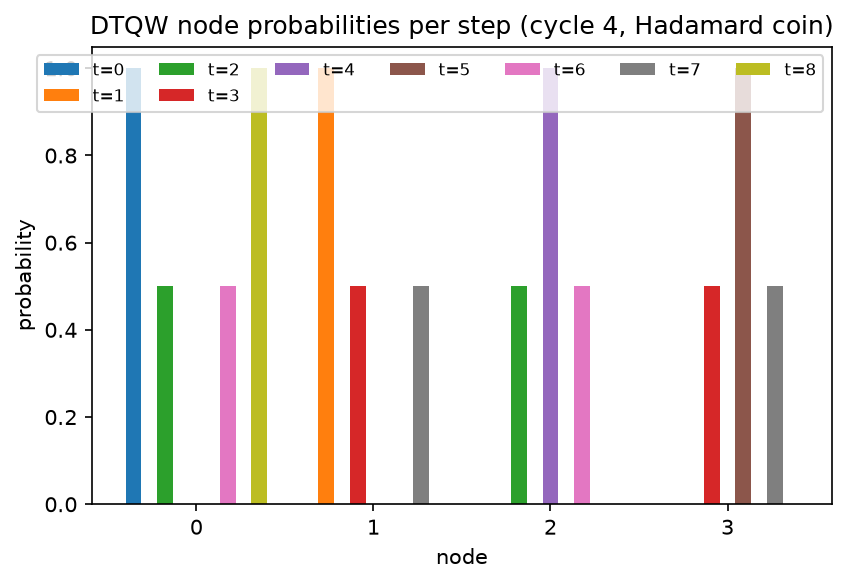

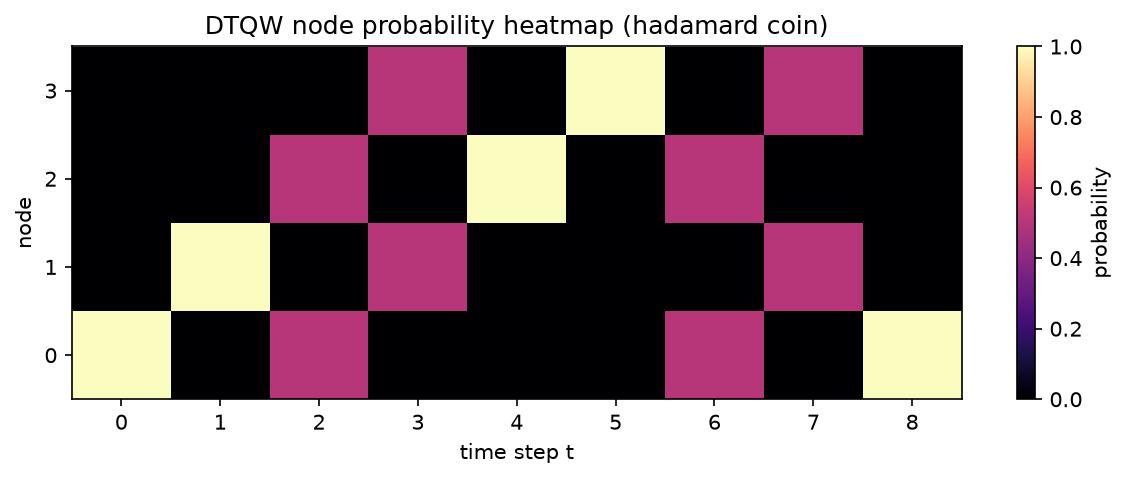

In [22]:
# --- figures -----------------------------------------------------------------
evolution_png = FIGDIR / "walk_evolution.png"
heatmap_png = FIGDIR / "walk_heatmap.png"

plot_walk_evolution(G, STEPS, kind="hadamard", start_node=ORDER[0],
                    out_path=evolution_png,
                    title="DTQW node probabilities per step (cycle 4, Hadamard coin)")
plot_walk_heatmap(G, STEPS, kind="hadamard", start_node=ORDER[0], out_path=heatmap_png)

print("wrote", evolution_png)
print("wrote", heatmap_png)
display(Image(filename=str(evolution_png)))
display(Image(filename=str(heatmap_png)))

## 6. Quantum network creation

`[PROPOSED]` A quantum network is a weighted undirected graph $G = (V, E)$: $V$ are quantum nodes
(endpoints or repeaters) and $E$ are quantum communication links, each carrying five
routing-relevant quantities.

| Metric | Range | Meaning in this prototype |
| --- | --- | --- |
| `distance_km` | $\ge 0$ | Physical link length in kilometres. |
| `noise` | $[0,1]$ | Dimensionless noise **severity score** for routing. This is *not* a calibrated error rate. |
| `latency_ms` | $\ge 0$ | One-way classical / control latency in milliseconds. |
| `fidelity` | $[0,1]$ | Per-hop state-transfer fidelity as **declared by this model**. |
| `reliability` | $[0,1]$ | Link availability probability. |

> `[PROPOSED]` **These five metrics are synthetic and, by convention, uncorrelated.** In a real
> deployment `distance` drives attenuation, `noise` and `reliability` are consequences of it, and
> `latency` includes the classical feed-forward round trip. This prototype keeps them as
> *independent* inputs so that the routing coefficients $\alpha, \beta, \gamma, \delta$ remain
> independently controllable. **That is a modelling convenience and nothing more.** None of the
> five is measured, and no coefficient set is calibrated against any apparatus.

Nodes carry a declared `memory_lifetime_ms` and an `is_repeater` flag. Neither is simulated:
`memory_lifetime_ms` only feeds a closed-form decay *estimate*, and `is_repeater` only selects
which penalty the router charges.

The example network is the hand-designed A–F graph used throughout the project:

```
A --- B --- C --- D
 \            /
  \  E --- F
```

with links `A-B`, `B-C`, `C-D` (the long, clean upper branch), `A-E`, `E-F`, `F-D` (the short,
lossy, slow lower branch) and `C-F` (one extra link so the two branches can cross over). The metric
assignment is chosen so the routing problem is **not** degenerate: which branch wins depends on the
coefficients, which is exactly the trade-off the cost function is meant to expose.

In [23]:
NET = build_example_network()
print(repr(NET))
print("name              :", NET.name)
print("connected         :", NET.is_connected())
print("has_path A -> F   :", NET.has_path("A", "F"))
print("hop lengths       :", NET.hop_lengths())
print()
print("=== edge table ===")
print(NET.edge_table().to_string(index=False))
print()
print("=== node attributes ===")
nodes_frame = pd.DataFrame(
    [{"node": n, **NET.node(n)} for n in NET.nodes])
print(nodes_frame.to_string(index=False))

QuantumNetwork(name='BQT-MDQW/example-6-node', nodes=6, links=7, connected=True)
name              : BQT-MDQW/example-6-node
connected         : True
has_path A -> F   : True
hop lengths       : [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3]

=== edge table ===
source target  distance_km  noise  latency_ms  fidelity  reliability
     A      B        120.0   0.05         2.0      0.97         0.99
     A      E        160.0   0.22         8.0      0.88         0.92
     B      C        140.0   0.06         2.5      0.96         0.99
     C      D        110.0   0.05         2.0      0.97         0.99
     C      F         90.0   0.10         4.0      0.93         0.96
     D      F        100.0   0.20         7.0      0.90         0.93
     E      F        150.0   0.30        11.0      0.82         0.88

=== node attributes ===
node  memory_lifetime_ms  is_repeater
   A               800.0        False
   B               800.

In [24]:
# --- metric ranges, which is what the min-max normalisation works from --------
ranges = NET.metric_ranges()
print("=== metric ranges across every link (min, max) ===")
for key, (low, high) in ranges.items():
    print("  {:<13s} min = {:<8.4f}  max = {:<8.4f}  span = {:.4f}".format(key, low, high, high - low))
print()
table = NET.edge_table()
print("=== minmax_normalize applied to distance_km ===")
normalised = minmax_normalize(table["distance_km"].tolist())
shown = sorted(set(table["distance_km"]))
print("  raw -> normalised")
for value in shown:
    print("   {:<8.2f} -> {:.6f}   (links: {})".format(
        value, normalised[value],
        int((table["distance_km"] == value).sum())))
print()
print("This is what makes alpha/beta/gamma/delta comparable: a 400 km span and a 20 ms control")
print("latency are otherwise on incommensurable scales and no single weight set would transfer")
print("between networks. A *constant* column normalises to 0.0 everywhere, so a metric with no")
print("variation contributes nothing rather than an arbitrary constant.")
print()
print("  constant column ->", minmax_normalize([5.0, 5.0, 5.0]))
print("  empty column    ->", minmax_normalize([]))

=== metric ranges across every link (min, max) ===
  distance_km   min = 90.0000   max = 160.0000  span = 70.0000
  noise         min = 0.0500    max = 0.3000    span = 0.2500
  latency_ms    min = 2.0000    max = 11.0000   span = 9.0000
  fidelity      min = 0.8200    max = 0.9700    span = 0.1500
  reliability   min = 0.8800    max = 0.9900    span = 0.1100

=== minmax_normalize applied to distance_km ===
  raw -> normalised
   90.00    -> 0.000000   (links: 1)
   100.00   -> 0.142857   (links: 1)
   110.00   -> 0.285714   (links: 1)
   120.00   -> 0.428571   (links: 1)
   140.00   -> 0.714286   (links: 1)
   150.00   -> 0.857143   (links: 1)
   160.00   -> 1.000000   (links: 1)

This is what makes alpha/beta/gamma/delta comparable: a 400 km span and a 20 ms control
latency are otherwise on incommensurable scales and no single weight set would transfer
between networks. A *constant* column normalises to 0.0 everywhere, so a metric with no
variation contributes nothing rather than an 

In [25]:
# --- random_network determinism ----------------------------------------------
net_a = random_network(n_nodes=12, avg_degree=3, seed=SEED)
net_b = random_network(n_nodes=12, avg_degree=3, seed=SEED)
net_c = random_network(n_nodes=12, avg_degree=3, seed=SEED + 1)

same_seed_identical = net_a.edge_table().equals(net_b.edge_table())
different_seed_differs = not net_a.edge_table().equals(net_c.edge_table())

print("two calls with seed={} produce identical tables : {}".format(SEED, same_seed_identical))
print("seed={} vs seed={} produce different tables      : {}".format(
    SEED, SEED + 1, different_seed_differs))
print()
print("   {:<5s} {:<5s} {:<10s} {:<6s} {:<9s} {:<9s} {:<12s} {}".format(
    "src", "dst", "distance", "noise", "latency", "fidelity", "reliability", "seed"))
for (u, v), row in zip(net_a.links, net_a.edge_table().itertuples(index=False)):
    print("   {:<5s} {:<5s} {:<10.2f} {:<6.3f} {:<9.2f} {:<9.4f} {:<12.4f} {}".format(
        u, v, row.distance_km, row.noise, row.latency_ms, row.fidelity, row.reliability, SEED))
print()
print("connected:", net_a.is_connected(), "| a different seed:", net_c.is_connected())
print("edges: seed {} -> {}   seed {} -> {}".format(
    SEED, net_a.graph.number_of_edges(), SEED + 1, net_c.graph.number_of_edges()))

two calls with seed=20260930 produce identical tables : True
seed=20260930 vs seed=20260931 produce different tables      : True

   src   dst   distance   noise  latency   fidelity  reliability  seed
   N0    N3    343.26     0.086  9.61      0.9727    0.9677       20260930
   N0    N9    218.68     0.305  7.91      0.8586    0.9537       20260930
   N1    N5    330.95     0.119  18.99     0.8777    0.9635       20260930
   N1    N6    244.98     0.083  10.16     0.8464    0.9843       20260930
   N1    N8    311.47     0.221  4.47      0.8832    0.9016       20260930
   N1    N10   86.79      0.304  3.12      0.9182    0.9930       20260930
   N2    N8    332.24     0.210  15.40     0.9233    0.8734       20260930
   N2    N9    64.58      0.220  9.87      0.8625    0.9282       20260930
   N3    N6    276.14     0.028  11.54     0.8266    0.9069       20260930
   N3    N9    251.88     0.277  7.58      0.8757    0.9814       20260930
   N3    N10   243.83     0.092  18.24     0.9401

wrote

 C:\Users\Sanju\AppData\Local\Temp\bqt_mdqw_demo_figures\network_topology.png
cyan = ordinary node, amber = is_repeater, edge label = declared fidelity


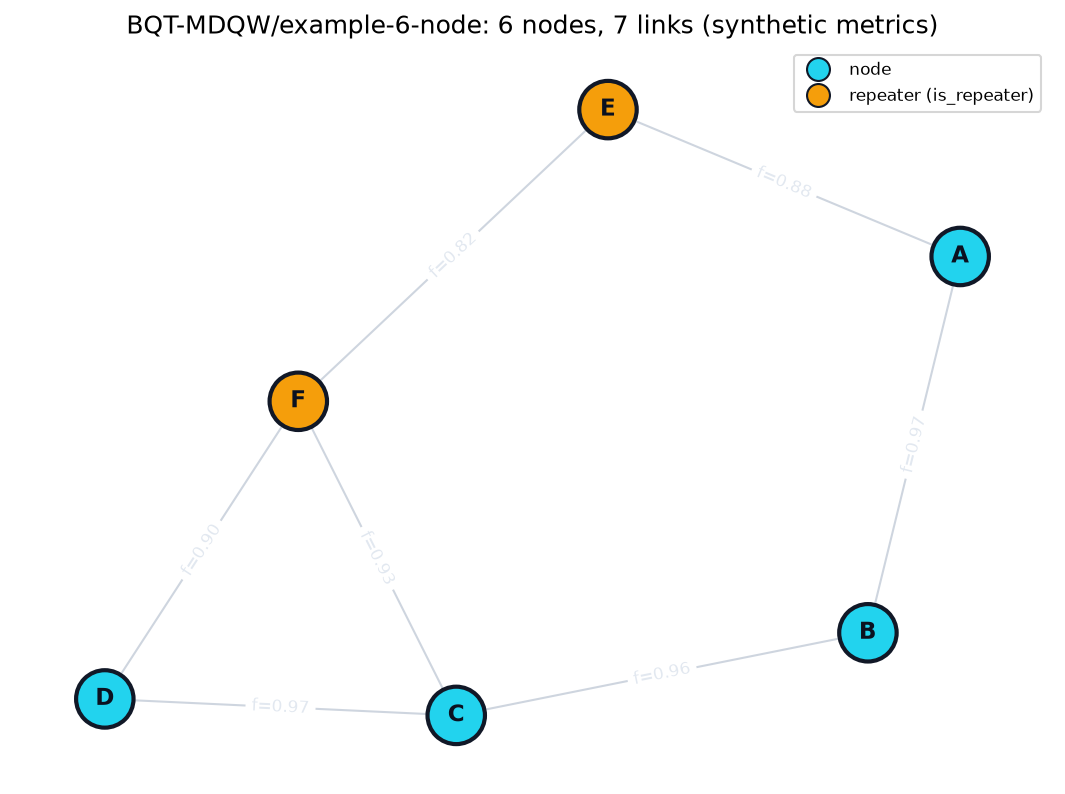

In [26]:
# --- topology figure ----------------------------------------------------------
topology_png = FIGDIR / "network_topology.png"
plot_network_topology(NET, FIGDIR)
print("wrote", topology_png)
print("cyan = ordinary node, amber = is_repeater, edge label = declared fidelity")
display(Image(filename=str(topology_png)))

## 7. MDQW-inspired routing

`[PROPOSED]` The whole of this section. No external citation, no hardware validation.

### The link cost

For a link $e = (u,v)$:

$$
C(e) = \alpha\,\hat{d}_e + \beta\,\hat{n}_e + \gamma\,\hat{\ell}_e
     + \delta\,(1 - \hat{f}_e) + \rho\,(1 - \hat{r}_e)
$$

where each hat is the metric min-max normalised over **every link in the network** (section 6).
`fidelity` and `reliability` enter as *penalties*, so a high value is good.

### The node term

A route's total also accumulates a term per **intermediate** node:

$$
N(v) = \texttt{hop\_penalty} \quad \text{or} \quad \texttt{repeater\_penalty}
     + \texttt{qw\_prior\_weight} \cdot \pi(v)
$$

with the second term active only when the walk prior is enabled. Source and destination are exempt.
`repeater_penalty` defaults to `hop_penalty`; this project lets it be a multiple of it when it wants
to say "a repeater must hold and regenerate entanglement, a plain relay need only buffer".

### Two honest caveats about optimality

1. The Dijkstra baseline searches with $C(e)$ **only**; MDQW searches with $C(e) + N(v)$. **Their
   objective functions differ**, so comparing raw `total_cost` between them is meaningless. The fair
   cross-algorithm number is `edge_cost`, which both are scored with. Section 8 reports it.
2. The walk prior is a **heuristic** and voids cost-optimality even for MDQW's own objective. It
   is **off by default**, and when it is on, `is_cost_optimal` is `False`.

### Why A* is still optimal here

The heuristic is the minimum incident edge cost at the current node. Any path from $v$ to the goal
must cross at least one link, and all node terms are non-negative, so this is a valid lower bound
on the remaining cost. The search is therefore optimal for its own objective, and
`is_cost_optimal = True` in that mode.

In [27]:
WEIGHTS = RoutingWeights(**DEFAULT_WEIGHTS)
CONFIG = MDQWConfig(weights=WEIGHTS, mode="astar", use_qw_prior=False)

print("default weights (DEFAULT_WEIGHTS):", DEFAULT_WEIGHTS)
print("resolved weights               :", WEIGHTS.as_dict())
print("config                         : mode={!r}, use_qw_prior={}, qw_prior_weight={}, "
      "prior_steps={}, max_hops={}".format(
          CONFIG.mode, CONFIG.use_qw_prior, CONFIG.qw_prior_weight,
          CONFIG.prior_steps, CONFIG.max_hops))
print()

ROUTER = MDQWRouter(NET, CONFIG)
ROUTE = ROUTER.route("A", "F")
print("--- MDQW A* A -> F ---")
print(ROUTE.describe())
print()
print("is_cost_optimal :", ROUTE.is_cost_optimal)
print("notes           :", ROUTE.notes)
print("algorithm       :", ROUTE.algorithm)
print("isinstance RouteResult:", isinstance(ROUTE, RouteResult))
print()
print("--- per-link breakdown ---")
edges_frame = pd.DataFrame([e.as_dict() for e in ROUTE.edges])
print(edges_frame.to_string(index=False))
print()
print("edge_cost check  sum(C(e)) = {:.6f}   reported edge_cost = {:.6f}".format(
    edges_frame["cost"].sum(), ROUTE.edge_cost))
print("node_cost check  sum(N(v)) = {:.6f}   reported node_cost  = {:.6f}".format(
    sum(ROUTER.node_cost(n) for n in ROUTE.path[1:-1]), ROUTE.node_cost))
print("total = edge + node       = {:.6f}   reported total_cost = {:.6f}".format(
    ROUTE.edge_cost + ROUTE.node_cost, ROUTE.total_cost))

default weights (DEFAULT_WEIGHTS): {'alpha': 1.0, 'beta': 1.0, 'gamma': 0.5, 'delta': 1.5, 'rho': 0.25}
resolved weights               : {'alpha': 1.0, 'beta': 1.0, 'gamma': 0.5, 'delta': 1.5, 'rho': 0.25, 'hop_penalty': 0.0, 'repeater_penalty': 0.0}
config                         : mode='astar', use_qw_prior=False, qw_prior_weight=0.0, prior_steps=8, max_hops=None

--- MDQW A* A -> F ---
Selected path: A -> B -> C -> F
Algorithm    : MDQW A*
Total cost   : 2.0899 (edge 2.0899 + node 0.0000)
Hop count    : 3
Distance     : 350.00 km
Noise (sum)  : 0.2100
Latency      : 8.50 ms
Fidelity est.: 0.866016

is_cost_optimal : True
notes           : Optimal for the stated objective.
algorithm       : MDQW A*
isinstance RouteResult: True

--- per-link breakdown ---
source target  distance_km  noise  latency_ms  fidelity  reliability     cost
     A      B        120.0   0.05         2.0      0.97         0.99 0.428571
     B      C        140.0   0.06         2.5      0.96         0.99 0.882063

In [28]:
# --- the effect of hop_penalty ------------------------------------------------
# On this network the two candidates are A -> B -> C -> F (2 non-repeater
# intermediates, edge cost 2.089928) and A -> E -> F (1 repeater intermediate,
# edge cost 7.179567), so the crossing point is predictable in closed form.
print("{:>8s}  {:<20s} {:>10s} {:>10s} {:>10s} {:>5s}".format(
    "hop_pen.", "path", "edge_cost", "node_cost", "total_cost", "hops"))
print("-" * 72)
hop_rows = []
for penalty in (0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 5.0, 5.5, 8.0):
    result = MDQWRouter(NET, MDQWConfig(weights=RoutingWeights(**{**DEFAULT_WEIGHTS,
                                                                 "hop_penalty": penalty}))).route("A", "F")
    print("{:>8}  {:<20s} {:>10.4f} {:>10.4f} {:>10.4f} {:>5d}".format(
        penalty, " -> ".join(result.path), result.edge_cost, result.node_cost,
        result.total_cost, result.hop_count))
    hop_rows.append({"hop_penalty": penalty, "path": " -> ".join(result.path),
                     "hop_count": result.hop_count, "edge_cost": result.edge_cost,
                     "node_cost": result.node_cost, "total_cost": result.total_cost})
hop_frame = pd.DataFrame(hop_rows)
print("-" * 72)
print()
crossing = 7.179567 - 2.089928
print("The selected path switches from A -> B -> C -> F to A -> E -> F between")
print("hop_penalty = 5.0 and 5.5. The analytic crossing is the point where")
print("   2.089928 + 2*h  ==  7.179567 + 1*h    =>    h = {:.6f}".format(crossing))
print("which is exactly what the sweep above shows.")

hop_pen.  path                  edge_cost  node_cost total_cost  hops
------------------------------------------------------------------------
     0.0  A -> B -> C -> F         2.0899     0.0000     2.0899     3
    0.25  A -> B -> C -> F         2.0899     0.5000     2.5899     3
     0.5  A -> B -> C -> F         2.0899     1.0000     3.0899     3
     1.0  A -> B -> C -> F         2.0899     2.0000     4.0899     3
     2.0  A -> B -> C -> F         2.0899     4.0000     6.0899     3
     4.0  A -> B -> C -> F         2.0899     8.0000    10.0899     3
     5.0  A -> B -> C -> F         2.0899    10.0000    12.0899     3
     5.5  A -> E -> F              7.1796     5.5000    12.6796     2
     8.0  A -> E -> F              7.1796     8.0000    15.1796     2
------------------------------------------------------------------------

The selected path switches from A -> B -> C -> F to A -> E -> F between
hop_penalty = 5.0 and 5.5. The analytic crossing is the point where
   2.089928 +

In [29]:
# --- the walk-informed prior mode --------------------------------------------
# quantum_walk_prior needs a REGULAR graph; the real network has degrees
# {1,2,3}, so walkable_proxy derives a regular surrogate. The surrogate is used
# ONLY to shape the prior: its edges are not physical quantum links.
PROXY, STRATEGY = walkable_proxy(NET.to_networkx())
PROXY_DEGREES = [degree for _, degree in PROXY.degree()]
print("walkable_proxy strategy      :", STRATEGY)
print("real degrees                 :", dict(NET.to_networkx().degree()))
print("proxy degrees                :", dict(PROXY.degree()), "(m = {} regular)".format(
    PROXY_DEGREES[0]))
print("proxy edges are not physical quantum links; the proxy carries no metrics.")
print()

PRIOR = quantum_walk_prior(PROXY, steps=8, kind="hadamard", start_node="A")
print("quantum_walk_prior(proxy, steps=8):")
for node, value in PRIOR.items():
    print("   node {}  salience {:.6f}".format(node, value))
print("   max = {:.6f} (rescaled so the peak is 1), all values in [0, 1]: {}".format(
    max(PRIOR.values()), all(0.0 <= v <= 1.0 for v in PRIOR.values())))
print()

QW_CONFIG = MDQWConfig(weights=WEIGHTS, mode="astar", use_qw_prior=True,
                       qw_prior_weight=1.0, prior_steps=8)
QW_ROUTER = MDQWRouter(NET, QW_CONFIG, prior=PRIOR)
QW_ROUTE = QW_ROUTER.route("A", "F")
print("--- MDQW A* + QW-prior, A -> F ---")
print(QW_ROUTE.describe())
print()
print("algorithm       :", QW_ROUTE.algorithm)
print("is_cost_optimal :", QW_ROUTE.is_cost_optimal, "   <-- the honesty flag")
print("notes           :", QW_ROUTE.notes)
print()
print("On this instance the prior happens not to change the selected path, so edge_cost is")
print("unchanged at {:.6f}; only the node term rose to {:.6f}.".format(
    QW_ROUTE.edge_cost, QW_ROUTE.node_cost))
print("The flag is still False, and would be False even if the path had not changed: the")
print("guarantee is what was lost, not the answer.")

walkable_proxy strategy      : complete-graph-fallback
real degrees                 : {'A': 2, 'B': 2, 'C': 3, 'D': 2, 'E': 2, 'F': 3}
proxy degrees                : {'A': 5, 'B': 5, 'C': 5, 'D': 5, 'E': 5, 'F': 5} (m = 5 regular)
proxy edges are not physical quantum links; the proxy carries no metrics.

quantum_walk_prior(proxy, steps=8):
   node A  salience 1.000000
   node B  salience 0.862052
   node C  salience 0.513925
   node D  salience 0.505831
   node E  salience 0.578363
   node F  salience 0.474904
   max = 1.000000 (rescaled so the peak is 1), all values in [0, 1]: True

--- MDQW A* + QW-prior, A -> F ---
Selected path: A -> B -> C -> F
Algorithm    : MDQW A* +QW-prior
Total cost   : 3.4659 (edge 2.0899 + node 1.3760)
Hop count    : 3
Distance     : 350.00 km
Noise (sum)  : 0.2100
Latency      : 8.50 ms
Fidelity est.: 0.866016

algorithm       : MDQW A* +QW-prior
is_cost_optimal : False    <-- the honesty flag
notes           : Quantum-walk prior is a heuristic; cost-optim

In [30]:
# --- enumerate every candidate path so the choice is legible ------------------
ENUM = enumerate_routes(NET, "A", "F", config=CONFIG, max_paths=64, max_hops=8)
cols = ["path", "hop_count", "edge_cost", "total_distance_km", "total_noise",
        "mean_noise", "estimated_fidelity", "total_latency_ms", "selected"]
print("all {} simple A -> F paths, ranked by edge cost:".format(len(ENUM)))
print(ENUM[cols].to_string(index=False))
print()
best = ENUM.iloc[0]
worst = ENUM.iloc[-1]
print("cheapest  : {}  edge_cost = {:.6f}   selected = {}".format(
    best["path"], best["edge_cost"], best["selected"]))
print("dearest   : {}  edge_cost = {:.6f}   selected = {}".format(
    worst["path"], worst["edge_cost"], worst["selected"]))
print("ratio     : {:.3f}x".format(worst["edge_cost"] / best["edge_cost"]))
print()
print("The short 2-hop lower branch A -> E -> F is geometrically cheaper in distance (310 km vs")
print("350 km) but its links are lossy and slow, so after normalisation it costs {:.6f} against".format(
    worst["edge_cost"]))
print("{:.6f}. This is the trade-off the coefficients are supposed to expose.".format(best["edge_cost"]))

all 3 simple A -> F paths, ranked by edge cost:
                 path  hop_count  edge_cost  total_distance_km  total_noise  mean_noise  estimated_fidelity  total_latency_ms  selected
     A -> B -> C -> F          3   2.089928              350.0         0.21        0.07            0.866016               8.5      True
A -> B -> C -> D -> F          4   3.453348              470.0         0.36        0.09            0.812938              13.5     False
          A -> E -> F          2   7.179567              310.0         0.52        0.26            0.721600              19.0     False

cheapest  : A -> B -> C -> F  edge_cost = 2.089928   selected = True
dearest   : A -> E -> F  edge_cost = 7.179567   selected = False
ratio     : 3.435x

The short 2-hop lower branch A -> E -> F is geometrically cheaper in distance (310 km vs
350 km) but its links are lossy and slow, so after normalisation it costs 7.179567 against
2.089928. This is the trade-off the coefficients are supposed to expose.


## 8. Dijkstra baseline

`[ESTABLISHED]` Dijkstra's single-source shortest-path algorithm. It is a **classical** graph
algorithm. It is **not** a quantum algorithm, and this module makes no attempt to run it on a
quantum computer — it is used purely as a well-understood reference point.

`DijkstraBaseline` searches the *identical* link cost $C(e)$ used by `MDQWRouter`, but with **no
node terms and no heuristic**, so it returns the true minimum-$C(e)$ path.

### The two different objective functions — read this before the verdict

| | search objective | optimal for it? |
| --- | --- | --- |
| `DijkstraBaseline` | $C(e)$ summed over links | yes, exactly |
| `MDQWRouter` (no prior) | $C(e) + N(v)$ | yes, for **its** objective |
| `MDQWRouter` (+ prior) | $C(e) + N(v) + w\pi(v)$ | **no** — the prior is a heuristic |

So `total_cost` is **not** a fair cross-algorithm number, and comparing it would be meaningless.
The fair metric is **`edge_cost`**, because it is computed the same way for every route regardless
of the node terms. Both columns are reported; neither algorithm is presented as better.

> **MDQW is not claimed to beat Dijkstra.** With no node terms and no prior, MDQW *is* A\* over the
> same cost, and on a graph this small it minimises the same objective — so a tie is the expected
> outcome, not a disappointment. What section 10 shows is what happens when the prior is switched
> on: it *breaks* cost-optimality.

In [31]:
DIJKSTRA = DijkstraBaseline(NET, WEIGHTS)
DIJKSTRA_ROUTE = DIJKSTRA.route("A", "F")

print("--- Dijkstra (classical baseline) A -> F ---")
print(DIJKSTRA_ROUTE.describe())
print()
print("algorithm       :", DIJKSTRA_ROUTE.algorithm)
print("is_cost_optimal :", DIJKSTRA_ROUTE.is_cost_optimal)
print("notes           :", DIJKSTRA_ROUTE.notes)
print()
print("total_cost of Dijkstra is the pure edge sum by construction (node_cost = {:.6f}).".format(
    DIJKSTRA_ROUTE.node_cost))

--- Dijkstra (classical baseline) A -> F ---
Selected path: A -> B -> C -> F
Algorithm    : Dijkstra (classical baseline)
Total cost   : 2.0899 (edge 2.0899 + node 0.0000)
Hop count    : 3
Distance     : 350.00 km
Noise (sum)  : 0.2100
Latency      : 8.50 ms
Fidelity est.: 0.866016

algorithm       : Dijkstra (classical baseline)
is_cost_optimal : True
notes           : Optimal for the stated objective.

total_cost of Dijkstra is the pure edge sum by construction (node_cost = 0.000000).


In [32]:
COMPARISON = compare_routes({
    "mdqw-default": ROUTE,
    "mdqw-qw-prior": QW_ROUTE,
    "dijkstra": DIJKSTRA_ROUTE,
})
pd.set_option("display.width", 200)
print("=== compare_routes ===")
print(COMPARISON[["label", "algorithm", "path", "hop_count", "edge_cost", "node_cost",
                  "total_cost", "estimated_fidelity", "is_cost_optimal",
                  "edge_cost_delta_vs_dijkstra", "hop_delta_vs_dijkstra",
                  "fidelity_delta_vs_dijkstra"]].to_string(index=False))
print()
print("=== summarise_comparison (the REAL verdict) ===")
SUMMARY = summarise_comparison(COMPARISON)
print(SUMMARY.to_string(index=False))
print()
print()
print(">>> verdict: " + str(SUMMARY.iloc[0]["verdict"]))
print()
print("Read that literally: on this instance every MDQW configuration tied Dijkstra on the only")
print("metric both are scored with. The tie is expected, because without node terms and without")
print("the prior the two searches minimise the same objective. The QW-prior row is a tie too, but")
print("it is a tie it had no guarantee of -- its is_cost_optimal flag is False.")

=== compare_routes ===
        label                     algorithm             path  hop_count  edge_cost  node_cost  total_cost  estimated_fidelity  is_cost_optimal  edge_cost_delta_vs_dijkstra  hop_delta_vs_dijkstra  fidelity_delta_vs_dijkstra
 mdqw-default                       MDQW A* A -> B -> C -> F          3   2.089928   0.000000    2.089928            0.866016             True                          0.0                      0                         0.0
mdqw-qw-prior             MDQW A* +QW-prior A -> B -> C -> F          3   2.089928   1.375976    3.465904            0.866016            False                          0.0                      0                         0.0
     dijkstra Dijkstra (classical baseline) A -> B -> C -> F          3   2.089928   0.000000    2.089928            0.866016             True                          0.0                      0                         0.0

=== summarise_comparison (the REAL verdict) ===
 configurations  mdqw_lower_edge_cos

In [33]:
# --- what RoutingError looks like, and why it is a feature --------------------
print("=== validation is explicit, not silent ===")
try:
    RoutingWeights(alpha=0.0, beta=0.0, gamma=0.0, delta=0.0, rho=0.0)
except RoutingError as exc:
    print("all-zero weights ->", type(exc).__name__, ":", exc)
try:
    EdgeMetrics(distance_km=-1.0, noise=0.1, latency_ms=1.0, fidelity=0.9, reliability=0.9)
except Exception as exc:
    print("negative distance ->", type(exc).__name__, ":", exc)

# a genuinely disconnected pair, so the routing error is a real graph property
island = QuantumNetwork(name="island-demo")
island.add_node("X1")
island.add_node("X2")
island.add_link("X1", "X2", EdgeMetrics(50.0, 0.1, 3.0, 0.95, 0.98))
try:
    MDQWRouter(island, CONFIG).route("X1", "D")
except (RoutingError, KeyError) as exc:
    print("disconnected pair ->", type(exc).__name__, ":", str(exc)[:110], "...")
print()
print("A router that silently returned *some* path here would be lying.")

=== validation is explicit, not silent ===
all-zero weights -> RoutingError : at least one of alpha/beta/gamma/delta/rho must be positive; otherwise all link costs are identical and routing is degenerate
negative distance -> MetricValidationError : distance_km must be non-negative, got -1.0
disconnected pair -> KeyError : "unknown target 'D'" ...

A router that silently returned *some* path here would be lying.


## 9. Multi-hop simulation

> ### ⚠️ Naive sequential teleportation is **NOT** a repeater network
>
> `[PROPOSED]` `[SIMULATED]` Real quantum repeaters use **entanglement swapping**, **purification**
> and **quantum memories**. The model exercised here teleports **hop by hop** with **no entanglement
> swapping**, **no purification**, **no error correction**, **no repeater buffering and no
> repeater scheduling**. Its end-to-end fidelity must therefore be read as an *illustrative per-hop
> composition*, **not** as repeater-network performance.
>
> Additional, subtler gaps that matter just as much:
>
> * `[PROPOSED]` **No quantum memory decoherence is simulated.** `memory_decay_estimate` is the
>   closed-form surrogate $\exp(-\text{latency}/\text{memory lifetime})$ — a *reported number*, not
>   a decoherence simulation — and the memory lifetimes themselves are declared model inputs.
> * `[PROPOSED]` **The payload is destroyed at every hop.** The state is re-prepared from
>   $\theta, \phi$ at the start of each hop, so this is *not* a state being carried through a noisy
>   chain; it is $k$ independent transfer experiments concatenated. That is why the product of the
>   per-hop numbers can be higher than the declared link product.
> * `[SIMULATED]` The noise mapping itself (`noise -> 5% capped depolarising`, `fidelity -> readout
>   error`) is a choice of this repository, not a calibrated device model.

### The three fidelity columns — they answer three different questions

| Column | Question | Where it comes from |
| --- | --- | --- |
| `simulated_end_to_end_fidelity` | What did the hop-by-hop Aer runs produce? | product of per-hop Bhattacharyya scores |
| `link_estimate_fidelity` | What does the network model *declare*? | product of per-link `fidelity` attributes; pure model input, no simulation |
| `attenuation_estimate_fidelity` | What if long links were penalised analytically? | product of $f \cdot e^{-d/L}$ with $L = 50$ km; pure arithmetic |

They must **not** be compared as though interchangeable.

In [34]:
MULTIHOP = simulate_route(NET, ROUTE, shots=2048, seed=SEED)
print("isinstance MultiHopResult:", isinstance(MULTIHOP, MultiHopResult))
print("isinstance HopResult     :", all(isinstance(h, HopResult) for h in MULTIHOP.hops))
print()
print("--- describe() ---")
print(MULTIHOP.describe())

isinstance MultiHopResult: True
isinstance HopResult     : True

--- describe() ---
Path        : A -> B -> C -> F
Hop count   : 3
Distance    : 350.00 km
Noise (sum) : 0.2100
Latency     : 8.50 ms
Per-hop simulated fidelity:
  hop 0     A -> B     simulated=0.999931  declared=0.9700  shots=2048  mem_decay=0.9975
  hop 1     B -> C     simulated=0.999895  declared=0.9600  shots=2048  mem_decay=0.9969
  hop 2     C -> F     simulated=0.999931  declared=0.9300  shots=2048  mem_decay=0.9980
Simulated end-to-end fidelity : 0.999757
Declared link product         : 0.866016
Attenuation estimate (L=50km) : 0.000790
Simulated minus declared      : +0.133741
CAVEAT: Naive sequential teleportation, as modelled here, is NOT equivalent to an optimised quantum repeater network. Real repeaters use entanglement swapping, purification, and quantum memories; the sequential model teleports hop-by-hop with no entanglement swapping, so its end-to-end fidelity should be read as an illustrative per-hop comp

In [35]:
hop_frame = pd.DataFrame([h.as_dict() for h in MULTIHOP.hops])
print("=== per-hop table ===")
print(hop_frame.to_string(index=False))
print()
print("=== the three end-to-end numbers, and the gap ===")
summary_row = MULTIHOP.as_dict()
print("simulated end-to-end fidelity : {:.6f}   (product of the per-hop Aer scores)".format(
    MULTIHOP.simulated_end_to_end_fidelity))
print("declared link product         : {:.6f}   (product of the link 'fidelity' attributes)".format(
    MULTIHOP.link_estimate_fidelity))
print("attenuation estimate (L=50km) : {:.6f}   (product of f * exp(-d/50))".format(
    MULTIHOP.attenuation_estimate_fidelity))
print("simulated minus declared      : {:+.6f}".format(MULTIHOP.simulated_vs_link_gap))
print()
print("The simulated column is *above* the declared one by {:+.6f}. That is not an error and it".format(
    MULTIHOP.simulated_vs_link_gap))
print("is not evidence that the links are better than declared. The two numbers are answers to")
print("different questions: the declared product is a model input that happens to sit below 1, while")
print("the simulated product is a Bhattacharyya coefficient between two near-50/50 distributions,")
print("which is bounded near 1 for a nearly uniform payload. Comparing them directly is exactly the")
print("mistake the table above is warning about.")
print()
print("per-hop product check: {} = {:.6f}".format(
    " * ".join("%.6f" % h.simulated_fidelity for h in MULTIHOP.hops),
    MULTIHOP.simulated_end_to_end_fidelity))

=== per-hop table ===
 hop_index source target  distance_km  noise_score  fidelity_hint  latency_ms  simulated_fidelity  shots  memory_lifetime_ms  ideal_fidelity  memory_decay_estimate
         0      A      B        120.0         0.05           0.97         2.0            0.999931   2048               800.0            0.97               0.997503
         1      B      C        140.0         0.06           0.96         2.5            0.999895   2048               800.0            0.96               0.996880
         2      C      F         90.0         0.10           0.93         4.0            0.999931   2048              2000.0            0.93               0.998002

=== the three end-to-end numbers, and the gap ===
simulated end-to-end fidelity : 0.999757   (product of the per-hop Aer scores)
declared link product         : 0.866016   (product of the link 'fidelity' attributes)
attenuation estimate (L=50km) : 0.000790   (product of f * exp(-d/50))
simulated minus declared      : +0

In [36]:
# --- one raw hop, so the bridge from link metrics to Aer is visible -----------
first_link = ROUTE.edges[0]
RAW = teleport_link_with_noise(ArbitraryState(theta=math.pi / 4.0, phi=0.7),
                               noise_score=first_link.noise,
                               fidelity_hint=first_link.fidelity,
                               shots=2048, seed=SEED)
print("teleport_link_with_noise on link {} -> {}:".format(first_link.source, first_link.target))
print("   input : noise_score = {:.2f}   fidelity_hint = {:.2f}".format(
    first_link.noise, first_link.fidelity))
print("   output:", {k: (round(v, 6) if isinstance(v, float) else v) for k, v in RAW.items()})
print()
print("The mapping is [PROPOSED]: p_depol = clip(noise, 0, 1) * 0.05 (capped at 5% per gate) and")
print("p_read = clip((1 - fidelity) * 0.25, 0, 0.5). It says nothing about any real apparatus.")
print("'bit_flips' is a disagreement count against the *majority* ideal outcome, not an error rate")
print("against a known per-shot truth -- the per-shot truth does not exist here, because the")
print("protocol destroyed the input.")

teleport_link_with_noise on link A -> B:
   input : noise_score = 0.05   fidelity_hint = 0.97
   output: {'measured_fidelity': 0.999931, 'noise_score': 0.05, 'fidelity_hint': 0.97, 'shots': 2048, 'bit_flips': 1007}

The mapping is [PROPOSED]: p_depol = clip(noise, 0, 1) * 0.05 (capped at 5% per gate) and
p_read = clip((1 - fidelity) * 0.25, 0, 0.5). It says nothing about any real apparatus.
'bit_flips' is a disagreement count against the *majority* ideal outcome, not an error rate
against a known per-shot truth -- the per-shot truth does not exist here, because the
protocol destroyed the input.


`fidelity_vs_hop_count` builds a linear chain of $h$ identical links for each hop count
$h = 1 \dots$ and measures how the three fidelity notions decay. Distance, latency, declared
fidelity and reliability are held constant and only `noise` is set. Note the deliberate
consequence: a **constant** `noise` column min-max normalises to `0.0` at every link, so the
normalised noise term contributes nothing to $C(e)$ and the chain's edge cost is identical at
every hop count. The raw `noise` still reaches the noise model unchanged, which is where the
simulated column comes from.

In [37]:
HOPS_FRAME = fidelity_vs_hop_count(noise_score=0.2, max_hops=4, shots=1024, seed=SEED)
print("=== fidelity_vs_hop_count(noise_score=0.2, max_hops=4, shots=1024) ===")
print(HOPS_FRAME.to_string(index=False))
print()
print("Three things to read off it, none of them flattering:")
print()
print("  1. The declared link product decays geometrically ({:+.6f} -> {:+.6f}) because it is a".format(
    HOPS_FRAME.iloc[0]["simulated_vs_link_gap"], HOPS_FRAME.iloc[-1]["simulated_vs_link_gap"]))
print("     product of a constant {:.2f} per hop.".format(HOPS_FRAME.iloc[0]["link_estimate_fidelity"]))
print("  2. The simulated column barely moves ({} -> {}). That is a property of the *measurement*,".format(
    round(HOPS_FRAME.iloc[0]["simulated_end_to_end_fidelity"], 6),
    round(HOPS_FRAME.iloc[-1]["simulated_end_to_end_fidelity"], 6)))
print("     not of link quality: the probe states are near-equatorial, so their ideal")
print("     distribution is close to 50/50 and a Bhattacharyya coefficient against it is near 1")
print("     however much noise is added. It is a weak score, which is exactly why it is reported")
print("     next to the two analytic columns instead of on its own.")
print("  3. The attenuation estimate collapses to {:.6f} by 4 hops, because exp(-100/50) is applied".format(
    HOPS_FRAME.iloc[-1]["attenuation_estimate_fidelity"]))
print("     per 100 km link. At L = 50 km that analytic model is brutally pessimistic for a")
print("     terrestrial chain, and the spread between the three columns is a measure of how much")
print("     the choice of fidelity notion -- not the network -- decides the answer.")
print()
display(Image(filename=str(FIGDIR / "walk_heatmap.png"))) if False else None

=== fidelity_vs_hop_count(noise_score=0.2, max_hops=4, shots=1024) ===
 hop_count  noise_score  shots_per_hop  probe_states  simulated_end_to_end_fidelity  link_estimate_fidelity  attenuation_estimate_fidelity  simulated_vs_link_gap
         1          0.2           1024             2                       0.999230                  0.9000                       0.121802               0.099230
         2          0.2           1024             2                       0.999330                  0.8100                       0.014836               0.189330
         3          0.2           1024             2                       0.998915                  0.7290                       0.001807               0.269915
         4          0.2           1024             2                       0.995340                  0.6561                       0.000220               0.339240

Three things to read off it, none of them flattering:

  1. The declared link product decays geometrically (+0.099230 

## 10. Results — the full seeded run

`[SIMULATED]` `run_all` executes the project's six experiments, writes every figure, and renders
`results.md` plus a summary CSV. We run it with `quick=True` (fewer trials and 512 shots) into a
**temporary directory**, so nothing in the repository is written or overwritten. The current
working directory is moved for the duration because `run_all` writes `docs/architecture.png`
*relative to the cwd*.

Everything in the next cells is what the run actually printed. Nothing is pre-written.

In [38]:
# The run is isolated: run_all writes docs/architecture.png *relative to the cwd*,
# so the cwd is moved into a throwaway temp directory and restored afterwards.
RUN_DIR = pathlib.Path(tempfile.mkdtemp(prefix="bqt_mdqw_demo_run_"))
RESULTS = None
_previous_cwd = pathlib.Path.cwd()
try:
    os.chdir(RUN_DIR)
    RESULTS = run_all(output_dir=RUN_DIR / "results", seed=SEED, quick=True)
finally:
    os.chdir(_previous_cwd)

print()
print("=" * 78)
print("run completed in {:.1f} s".format(RESULTS["elapsed_seconds"]))
print("errors          :", RESULTS["errors"] or "none")
print("figures written :", len(RESULTS["figures"]))
print("results.md      :", RESULTS["results_md"])
print("summary csv     :", RESULTS["summary_csv"])
print("architecture    :", RESULTS["architecture"])
print("=" * 78)

BQT-MDQW run -- ALL RESULTS ARE CLASSICAL SIMULATIONS ON SYNTHETIC DATA
  seed            : 20260930
  quick           : True
  output_dir      : C:\Users\Sanju\AppData\Local\Temp\bqt_mdqw_demo_run_z6z8j7cx\results
  shots (sweeps)  : 512
  random trials   : 3
  noise levels    : [0.0, 0.05, 0.1]
  prior (w, steps): [1.0, 4.0] x [4, 8]
  repeater counts : [0, 1]
  PYTHONHASHSEED  : None (provenance only; not required for reproducibility)
------------------------------------------------------------------------------
[1/6] manual network A -> F (MDQW, MDQW+walk prior, Dijkstra) ...


      paths: mdqw-default=A -> B -> C -> F (edge 2.0899); mdqw-qw-prior=A -> B -> C -> F (edge 2.0899); dijkstra=A -> B -> C -> F (edge 2.0899)


      verdict: All 2 MDQW configurations tied with Dijkstra.


      simulated end-to-end fidelity: mdqw-default=0.999989, mdqw-qw-prior=0.999989, dijkstra=0.999989


[2/6] random networks (n_nodes=12, n_trials=3) ...


...

  figures written: 11/11


  failures: none


  REMINDER: sequential hop-by-hop teleportation is not a quantum repeater network (no entanglement swapping, purification or memories).


  elapsed: 5.7 s



run completed in 5.7 s
errors          : none
figures written : 11
results.md      : C:\Users\Sanju\AppData\Local\Temp\bqt_mdqw_demo_run_z6z8j7cx\results\results.md
summary csv     : C:\Users\Sanju\AppData\Local\Temp\bqt_mdqw_demo_run_z6z8j7cx\results\results_summary.csv
architecture    : docs\architecture.png


In [39]:
# --- the run's own verdict lines ----------------------------------------------
meta_manual = RESULTS["metadata"]["manual_network"]
meta_random = RESULTS["metadata"]["random_network"]
meta_noise = RESULTS["metadata"]["noise_sweep"]
meta_weight = RESULTS["metadata"]["weight_sweep"]
meta_ablation = RESULTS["metadata"]["qw_prior_ablation"]
meta_hop = RESULTS["metadata"]["hop_penalty"]

print("=== what the run actually observed ===")
print("manual-network verdict            :", meta_manual["verdict"])
print("random-network counts (w/l/t)      :", RESULTS["counts"])
print("random networks connected / not   :", meta_random["connected_networks"], "/",
      meta_random["disconnected_networks"])
print("random networks matching Dijkstra  :", meta_random["matched_dijkstra_edge_cost"], "of",
      meta_random["trials_without_reachable_pair"] + meta_random["ties"]
      + meta_random["wins"] + meta_random["losses"], "compared")
print("noise sweep distinct edge costs   :", meta_noise["distinct_edge_costs"],
      "(paths:", meta_noise["distinct_paths"], ")")
print("noise sweep edge cost is constant :", meta_noise["edge_cost_is_constant"])
print("weight grid combinations / paths   :", meta_weight["combinations_recorded"], "recorded,",
      len(meta_weight["skipped"]), "skipped,", meta_weight["distinct_paths"], "distinct path(s)")
print("weight grid edge-cost range        :", [round(value, 4) for value in meta_weight["edge_cost_range"]])
print("QW-prior optimal / suboptimal      :", meta_ablation["edge_cost_still_optimal"], "/",
      meta_ablation["edge_cost_suboptimal"], " worst shortfall {:+.6f}".format(
          meta_ablation["max_edge_cost_difference"]))
print("hop-penalty sweep / repeater counts:", meta_hop["n_repeaters"], "->", meta_hop["distinct_paths"],
      "distinct paths over", meta_hop["hop_penalties"])
print("experiments or figures that failed :", RESULTS["errors"] or "none")
print()
print("Observations, read carefully:")
print()
print("  * The two algorithms TIE on the manual network. That is the expected outcome, because")
print("    without node terms and without the prior they minimise the same objective.")
print("  * Of the 3 seeded random networks, {} were disconnected, so only {} of them could be".format(
    meta_random["disconnected_networks"], meta_random["connected_networks"]))
print("    compared at all. Reported rather than hidden.")
print("  * The noise sweep produced {} distinct edge cost, because a constant noise column".format(
    meta_noise["distinct_edge_costs"]))
print("    min-max normalises to 0.0 at every link and so cannot influence C(e) at all.")
print("  * Switching the walk prior on left the edge cost optimal in {} of {} configurations,".format(
    meta_ablation["edge_cost_still_optimal"],
    meta_ablation["edge_cost_still_optimal"] + meta_ablation["edge_cost_suboptimal"]))
print("    and cost up to {:+.6f} in the worst case. That is the honest cost of the heuristic:".format(
    meta_ablation["max_edge_cost_difference"]))
print("    it is allowed to return a worse route, and it does.")

=== what the run actually observed ===
manual-network verdict            : All 2 MDQW configurations tied with Dijkstra.
random-network counts (w/l/t)      : {'wins': 0, 'losses': 0, 'ties': 9, 'matched': 9}
random networks connected / not   : 1 / 2
random networks matching Dijkstra  : 9 of 9 compared
noise sweep distinct edge costs   : 1 (paths: 1 )
noise sweep edge cost is constant : True
weight grid combinations / paths   : 12 recorded, 0 skipped, 1 distinct path(s)
weight grid edge-cost range        : [0.4471, 3.7328]
QW-prior optimal / suboptimal      : 6 / 2  worst shortfall +1.877601
hop-penalty sweep / repeater counts: [0, 1] -> 3 distinct paths over [0.0, 0.25, 0.5, 1.0, 2.0]
experiments or figures that failed : none

Observations, read carefully:

  * The two algorithms TIE on the manual network. That is the expected outcome, because
    without node terms and without the prior they minimise the same objective.
  * Of the 3 seeded random networks, 2 were disconnected, so only

In [40]:
FLAT = RESULTS["flat_frames"]
print("=== routes chosen on the example network ===")
print(FLAT["manual_network.routes"][
    ["label", "algorithm", "path", "hop_count", "edge_cost", "node_cost", "total_cost",
     "estimated_fidelity", "is_cost_optimal", "edge_cost_delta_vs_dijkstra"]
].to_string(index=False))
print()
print("=== all enumerated A -> F paths ===")
print(FLAT["manual_network.enumerated"][
    ["path", "hop_count", "edge_cost", "total_distance_km", "estimated_fidelity", "selected"]
].to_string(index=False))
print()
print("=== the multi-hop run inside the quick run (512 shots) ===")
print(FLAT["manual_network.multihop"][
    ["label", "path", "hop_count", "simulated_end_to_end_fidelity",
     "link_estimate_fidelity", "attenuation_estimate_fidelity", "simulated_vs_link_gap"]
].to_string(index=False))

=== routes chosen on the example network ===
        label                     algorithm             path  hop_count  edge_cost  node_cost  total_cost  estimated_fidelity  is_cost_optimal  edge_cost_delta_vs_dijkstra
 mdqw-default                       MDQW A* A -> B -> C -> F          3   2.089928   0.000000    2.089928            0.866016             True                          0.0
mdqw-qw-prior             MDQW A* +QW-prior A -> B -> C -> F          3   2.089928   1.375976    3.465904            0.866016            False                          0.0
     dijkstra Dijkstra (classical baseline) A -> B -> C -> F          3   2.089928   0.000000    2.089928            0.866016             True                          0.0

=== all enumerated A -> F paths ===
                 path  hop_count  edge_cost  total_distance_km  estimated_fidelity  selected
     A -> B -> C -> F          3   2.089928              350.0            0.866016      True
A -> B -> C -> D -> F          4   3.453348 

In [41]:
print("=== random-network aggregate over the weight presets ===")
print(FLAT["random_network.aggregate"].to_string(index=False))
print()
print("=== (alpha, delta) weight grid ===")
grid = FLAT["weight_sweep.grid"]
print(grid[["alpha", "delta", "path", "edge_cost", "hop_count", "estimated_fidelity"]]
      .to_string(index=False))
print()
print("=== walk-prior ablation ===")
print(FLAT["qw_prior_ablation.ablation_summary"].to_string(index=False))
print()
print("=== repeater hop-penalty switch points (from the same run) ===")
print(FLAT["hop_penalty.switch_points"].to_string(index=False))
print()
print("The weight grid rescales the cost of the chosen route ({} to {}) without changing which".format(
    round(grid["edge_cost"].min(), 4), round(grid["edge_cost"].max(), 4)))
print("route is chosen: {} distinct path across all {} combinations. That is a real finding about".format(
    grid["path"].nunique(), len(grid)))
print("this 6-node instance, not a general claim about the cost function.")

=== random-network aggregate over the weight presets ===
        preset  comparisons  mdqw_lower_edge_cost  dijkstra_lower_edge_cost  tied_edge_cost  matched_dijkstra_edge_cost  same_path_count  mean_dijkstra_edge_cost  mean_mdqw_edge_cost  mean_edge_cost_difference  mean_hop_difference  mean_dijkstra_distance_km  mean_mdqw_distance_km  mean_dijkstra_fidelity  mean_mdqw_fidelity
distance-heavy            3                     0                         0               3                           3                3                 3.120324             3.120324                        0.0                  0.0                 453.649225             453.649225                0.846928            0.846928
      balanced            3                     0                         0               3                           3                3                 3.501104             3.501104                        0.0                  0.0                 463.668506             463.668506             

--- network_topology.png : the example network behind experiment 1 ---
    exists: True  size: 62959


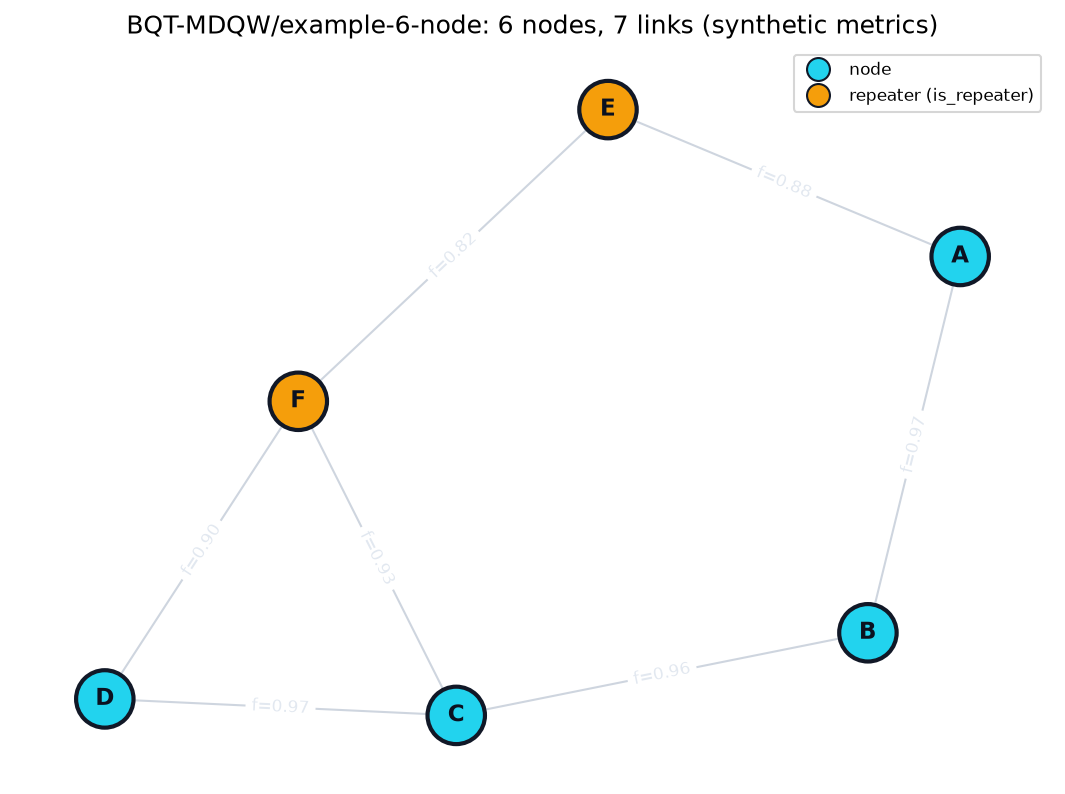


--- fidelity_vs_hops.png : simulated vs declared vs attenuated fidelity against hop count ---
    exists: True  size: 42451


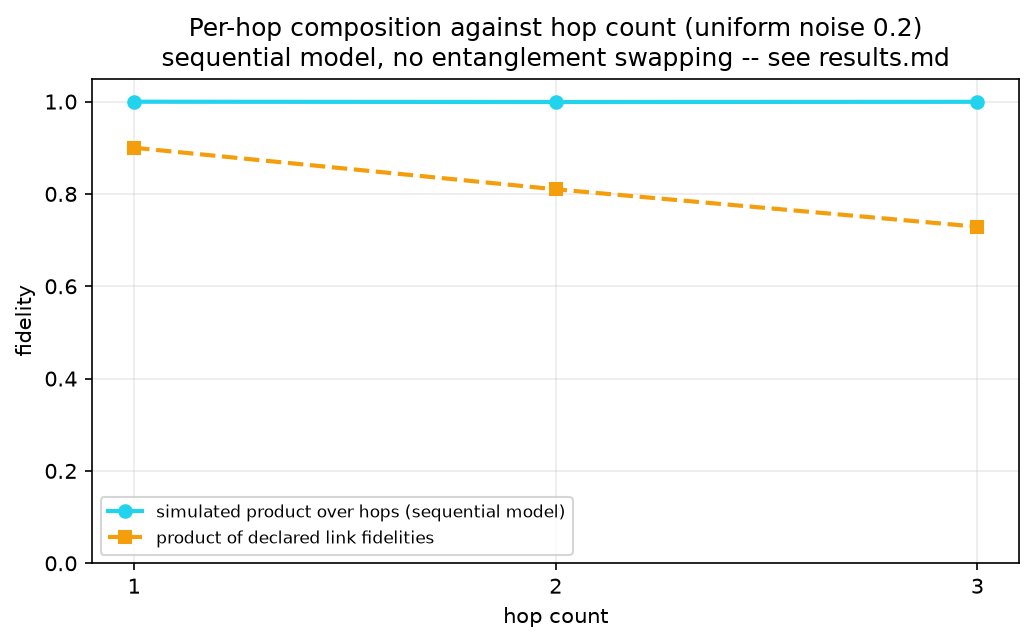


--- quantum_walk_heatmap.png : the DTQW node distribution, step by step ---
    exists: True  size: 30801


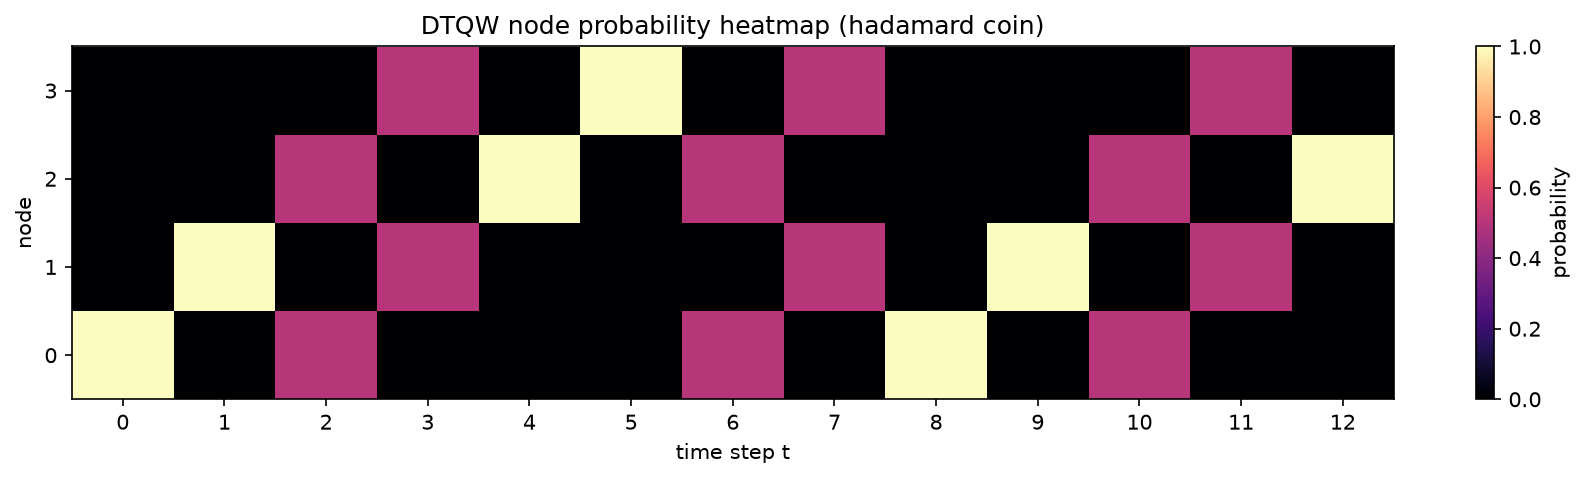


--- architecture.png : the seven-stage pipeline, with the planning/execution split ---
    exists: True


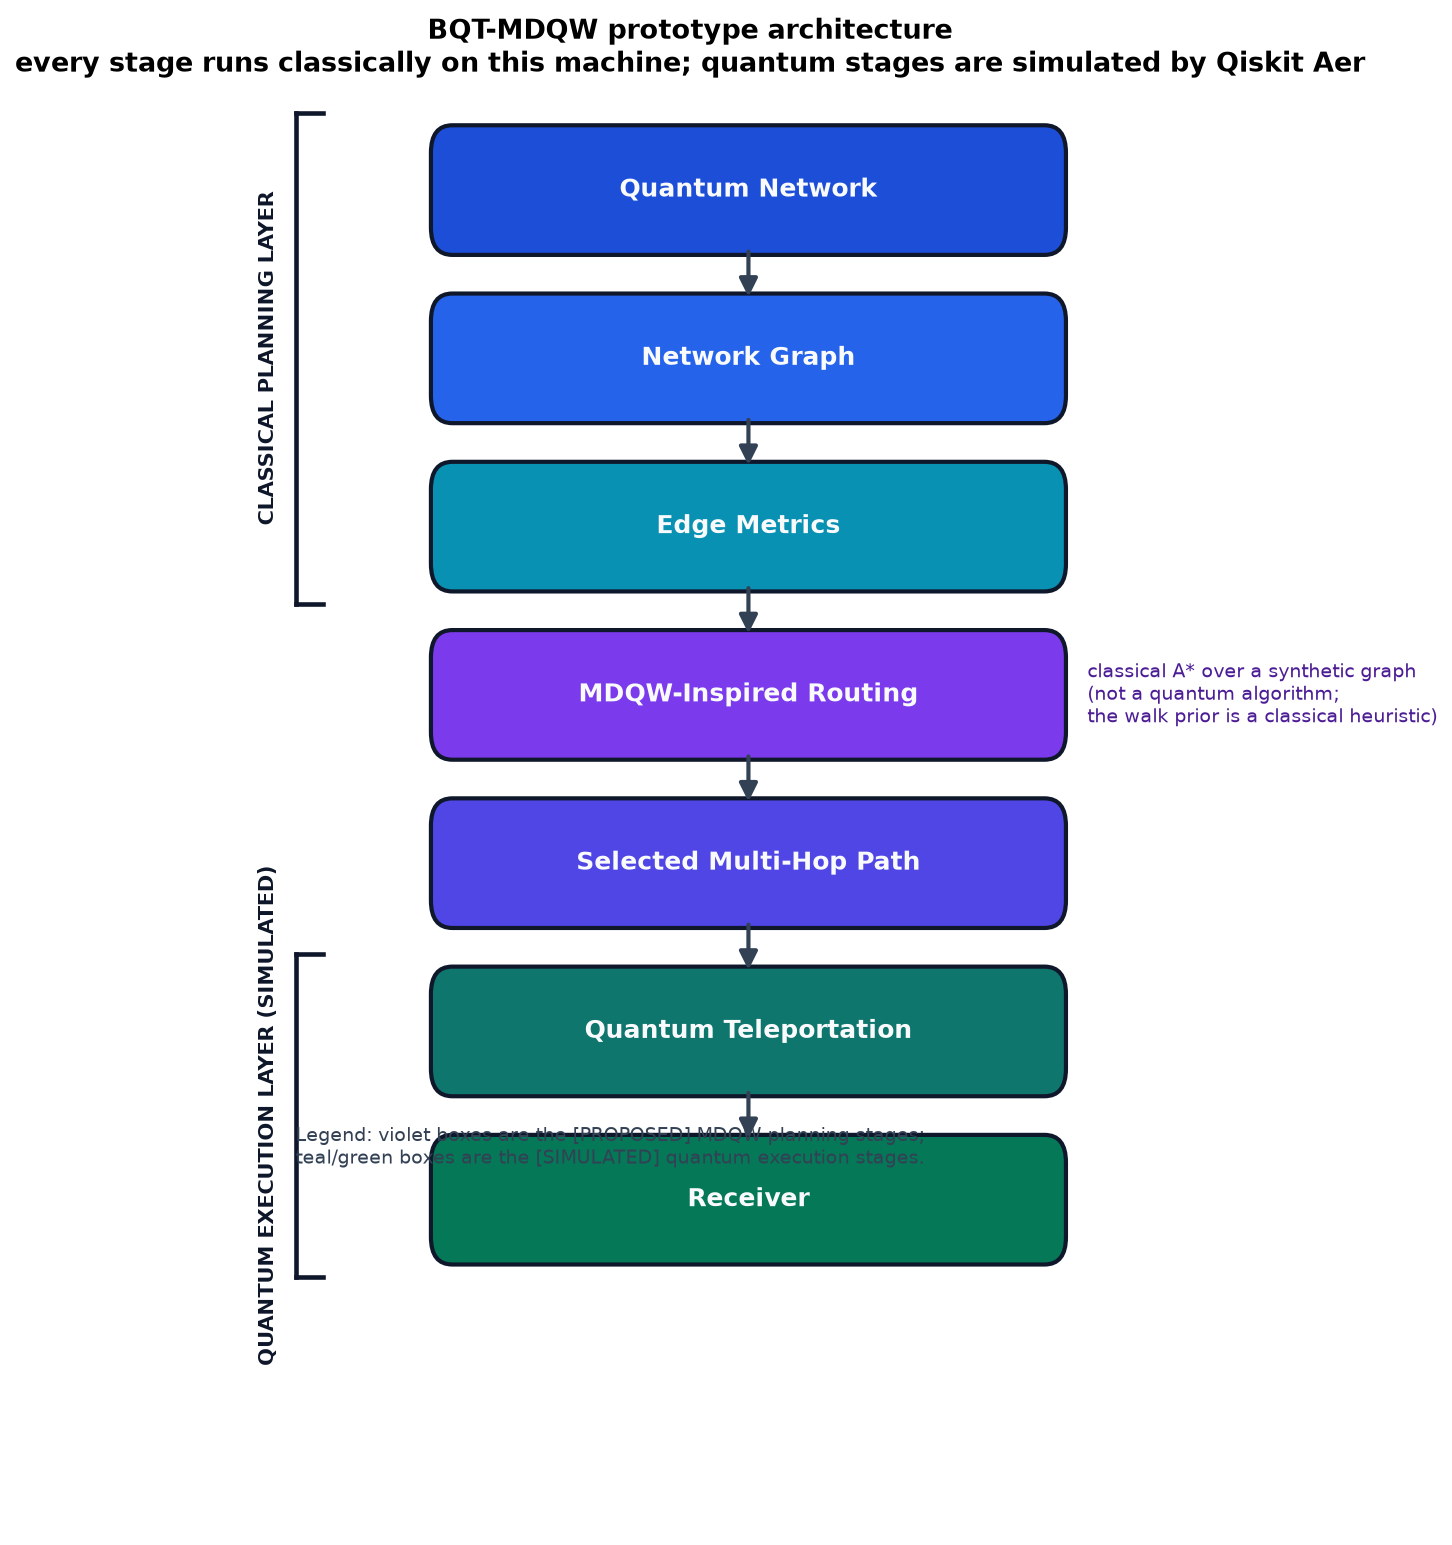

In [42]:
# --- three figures written by the run, plus the architecture diagram -----------
arch_png = FIGDIR / "architecture.png"
render_architecture_diagram(arch_png)

generated = [
    ("network_topology.png", "the example network behind experiment 1"),
    ("fidelity_vs_hops.png", "simulated vs declared vs attenuated fidelity against hop count"),
    ("quantum_walk_heatmap.png", "the DTQW node distribution, step by step"),
]
for filename, caption in generated:
    path = RUN_DIR / "results" / "figures" / filename
    print("--- {} : {} ---".format(filename, caption))
    print("    exists:", path.exists(), " size:", path.stat().st_size if path.exists() else 0)
    if path.exists():
        display(Image(filename=str(path)))
    print()

print("--- architecture.png : the seven-stage pipeline, with the planning/execution split ---")
print("    exists:", arch_png.exists())
display(Image(filename=str(arch_png)))

## 11. Limitations

The complete list, stated as plainly as possible.

1. **Everything here is a classical simulation.** `[SIMULATED]` Every quantum operation is executed
   by Qiskit Aer or by dense NumPy matrix-vector products. No quantum hardware, real optical link
   or network device was involved at any point.
2. **Routing is not a quantum algorithm.** `[PROPOSED]` MDQW routing is A\*; the baseline is
   Dijkstra. Both are classical graph searches. The quantum-walk "prior" is a plain
   `dict[node, float]` produced by a NumPy simulation and handed to the router.
3. **The walk component is demonstrative.** `[SIMULATED]` The coined DTQW runs on a 4-cycle because
   the shunt decomposition needs a regular graph — not because four nodes model a quantum network.
   Its Aer circuit applies the walk as a **single dense $(mn)\times(mn)$ unitary**, so the cost
   grows exponentially with the graph. Its only role is to supply a node prior.
4. **No quantum memories are simulated.** `[PROPOSED]` `memory_decay_estimate` is the closed-form
   $\exp(-\text{latency}/\text{lifetime})$ surrogate, not a decoherence simulation, and the memory
   lifetimes are declared model inputs.
5. **No entanglement distribution is modelled.** `[PROPOSED]` The bidirectional circuit is one
   composite six-qubit state built from two independent Bell pairs. Running both channels in one
   circuit hides the resource accounting a real two-way link must pay for, and it does **not**
   demonstrate physical simultaneous bidirectional teleportation.
6. **No entanglement swapping, no purification, no error correction, no repeater buffering, no
   repeater scheduling.** `[PROPOSED]` The multi-hop model is sequential and hop-by-hop. Its
   end-to-end fidelity is an illustrative per-hop composition, not repeater-network performance.
7. **The payload is re-prepared at every hop.** `[SIMULATED]` Because teleportation destroys the
   input, `simulate_route` runs $k$ independent transfer experiments and multiplies their scores.
   This is not a single quantum state being carried through a noisy chain.
8. **No hardware constraints.** `[PROPOSED]` There is no model of spectral bandwidth, wavelength
   multiplexing, detector dark counts, multiplexed-pair generation rate, finite key rate,
   decoherence during storage, or synchronisation between sites.
9. **The link metrics are synthetic and uncorrelated.** `[PROPOSED]` Distance, noise, latency,
   fidelity and reliability are drawn independently from chosen ranges. Their independence is a
   modelling convenience; in a real network they are strongly related.
10. **The fidelity score is a weak one.** `[SIMULATED]` `measured_fidelity` is a Bhattacharyya
    coefficient between two near-50/50 distributions, which is bounded near 1 for a near-uniform
    payload almost regardless of noise. The experiment that made this visible is the noise sweep,
    whose "simulated fidelity" *rises* slightly with noise. That is a property of the measurement,
    not evidence that noise helps.
11. **Simulation results do not establish physical performance.** Nothing in this notebook is
    evidence about a real quantum network, and no comparison here should be read as a claim about
    one.
12. **Some modes return non-optimal routes by design.** `[PROPOSED]` The walk-informed mode sets
    `is_cost_optimal = False` and says so in `notes`. In the sweep run above it left the edge cost
    optimal in most but not all configurations, and cost up to the reported shortfall in the worst.
    A router that can return a worse route by design is a heuristic, and is labelled as one.
13. **The walkable proxy is a surrogate.** `[PROPOSED]` `walkable_proxy` replaces an irregular
    network with a regular graph — in this run, a complete-graph fallback — purely so the walk has
    a fixed coin dimension. **The proxy's edges are not physical quantum links**, and the prior it
    produces is shaped by an artefact of that substitution.
14. **No claim of advantage is made anywhere.** There is no quantum speed-up, no scaling
    advantage, and no claim that MDQW routing beats Dijkstra. On the instances in this notebook
    they tie.

## 12. Future work

Each item below is `[PROPOSED]` unless tagged otherwise, and each is stated as work to be done —
none of it is present in this prototype.

### 12.1 Repeater modelling `[PROPOSED]`

Replace sequential teleportation with an actual repeater chain: entanglement **swapping** at each
repeater, **purification** of the swapped pairs, and a policy for when to attempt a swap versus
when to re-establish. The expected consequence is that end-to-end fidelity stops collapsing
geometrically with hop count, because the *repeaters* — not the links — become the bottleneck.
That claim is a prediction of the theory, **not** a result of this project, and the current
`fidelity_vs_hop_count` figure is not evidence for it.

### 12.2 Memory-aware scheduling `[PROPOSED]`

Give quantum memories real decoherence (a channel, not a closed-form estimate) and make the router
*time-aware*: a path's cost should depend on when the state arrives at each memory, not only on
which links it uses. Two paths with identical link costs are not equivalent if one of them makes a
relay wait past its coherence time. This needs a `max_hops`-style constraint on the search to
remain well posed.

### 12.3 Hardware-calibrated noise `[PROPOSED]`

Replace the illustrative `noise -> 5% depolarising` and `fidelity -> readout error` mappings with
gate-specific infidelities and a measured confusion matrix from a real apparatus, with per-qubit
variation. Only then does the fidelity column mean anything physical, and only then can a routing
objective be tuned against a real cost curve rather than a chosen one.

### 12.4 A genuine quantum implementation of the routing `[PROPOSED]`

The honest starting point is a quantum formulation of the walk itself — a walk that is *actually
executed* on hardware, with a circuit-level encoding and shot-based state preparation. A credible
route to a quantum routing algorithm would need an amplitude-amplification search layer
(`[ESTABLISHED]`: Grover / quantum Floyd–Warshall style ideas) on top, with a proven
query-complexity argument. **This notebook offers no evidence that such a construction would
help**, and no quantum advantage is claimed. The current classical router should be treated as the
baseline any such claim has to beat.

### 12.5 Scalable walk encodings `[PROPOSED]`

The dense $(mn)\times(mn)$ unitary is the binding constraint. Replacing it with a sparse,
local decomposition — a per-node coin/shift block, a graph-signal-processing operator, or a
`QuantumCircuit` synthesis path that emits a gate list with a growing count — is what would make a
walk demonstration run on hardware at all. Until that exists, the walk figures here are
illustrations, not experiments.

### 12.6 Related classical work that should be cited `[ESTABLISHED]`

The `[PROPOSED]` cost function in this repository has no external citation, and the project should
not be read as a literature review. The relevant classical literature includes multi-criteria
shortest-path methods and link-state routing with heterogeneous QoS, which is the honest home of
"minimise several normalised link metrics at once". The quantum-walk-for-routing literature exists
but is small and mostly theoretical; none of it is reproduced or verified here.

---

*`[SIMULATED]` BQT-MDQW research prototype. Every number in this notebook was produced by a
classical simulation on synthetic data. No quantum hardware was used, no link metric is calibrated
against a physical channel, no quantum advantage is claimed, and MDQW routing is not claimed to
beat Dijkstra.*